---
# 1️⃣ 환경 설정 및 데이터 로드

## 1-1) 라이브러리 설치

## 1-2) 라이브러리 import

In [131]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 변환: 문자열 → 딕셔너리
import ast

# 가설 검정
from scipy import stats
from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import chi2_contingency, shapiro, mannwhitneyu

# 파일 저장 시점 기록용
from datetime import datetime

# 링크 출력용
from IPython.display import Markdown, display

## 1-3) 시각화 폰트 설정

In [132]:
import platform
from matplotlib import rc

# 실행 환경의 OS 확인
os = platform.system()
if os == 'Windows':
    rc('font', family='Malgun Gothic')
elif os == 'Darwin':  # Mac
    rc('font', family='AppleGothic')
else:
    rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

## 1-4) 데이터 불러오기

원본 데이터에 index가 저장되어 있어 load시 불필요한 인덱스 제거

In [133]:
portfolio = pd.read_csv("portfolio.csv").drop(columns='Unnamed: 0')
profile = pd.read_csv("profile.csv").drop(columns='Unnamed: 0')
transcript = pd.read_csv("transcript.csv").drop(columns='Unnamed: 0')

---
# 2️⃣ 데이터 확인


- 컬럼 별 의미와 주요 정보를 스프레드시트로 정리

In [134]:
display(Markdown("[Google 스프레드시트 바로가기](https://docs.google.com/spreadsheets/d/1V83Znq1Ct7J30M6vaUc4zLEZCTCc3ok1YoKx_q4ATdc/edit?gid=90188944#gid=90188944"))

[Google 스프레드시트 바로가기](https://docs.google.com/spreadsheets/d/1V83Znq1Ct7J30M6vaUc4zLEZCTCc3ok1YoKx_q4ATdc/edit?gid=90188944#gid=90188944

## 2-1) portfolio (프로모션 정보)

In [135]:
portfolio

,reward,channels,difficulty,duration,offer_type,id
0,10,"['email', 'mobile', 'social']",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,10,"['web', 'email', 'mobile', 'social']",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,0,"['web', 'email', 'mobile']",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,5,"['web', 'email', 'mobile']",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,5,"['web', 'email']",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7
5,3,"['web', 'email', 'mobile', 'social']",7,7,discount,2298d6c36e964ae4a3e7e9706d1fb8c2
6,2,"['web', 'email', 'mobile', 'social']",10,10,discount,fafdcd668e3743c1bb461111dcafc2a4
7,0,"['email', 'mobile', 'social']",0,3,informational,5a8bc65990b245e5a138643cd4eb9837
8,5,"['web', 'email', 'mobile', 'social']",5,5,bogo,f19421c1d4aa40978ebb69ca19b0e20d
9,2,"['web', 'email', 'mobile']",10,7,discount,2906b810c7d4411798c6938adc9daaa5


In [136]:
print('\n', '='*60,'\n[데이터 구조 확인]')
display(portfolio.shape)

print('\n', '='*60,'\n[데이터 미리보기]\n')
display(portfolio.head(3))

print('\n', '='*60,'\n[기본 정보 요약]\n')
portfolio.info()

print('\n', '='*60,'\n[통계 정보 요약]\n')
display(portfolio.describe().T)


[데이터 구조 확인]


(10, 6)


[데이터 미리보기]



,reward,channels,difficulty,duration,offer_type,id
0,10,"['email', 'mobile', 'social']",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,10,"['web', 'email', 'mobile', 'social']",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,0,"['web', 'email', 'mobile']",0,4,informational,3f207df678b143eea3cee63160fa8bed



[기본 정보 요약]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   reward      10 non-null     int64 
 1   channels    10 non-null     object
 2   difficulty  10 non-null     int64 
 3   duration    10 non-null     int64 
 4   offer_type  10 non-null     object
 5   id          10 non-null     object
dtypes: int64(3), object(3)
memory usage: 612.0+ bytes

[통계 정보 요약]



,count,mean,std,min,25%,50%,75%,max
reward,10.0,4.2,3.583915,0.0,2.0,4.0,5.0,10.0
difficulty,10.0,7.7,5.831905,0.0,5.0,8.5,10.0,20.0
duration,10.0,6.5,2.321398,3.0,5.0,7.0,7.0,10.0


array([[<Axes: title={'center': 'reward'}>,
        <Axes: title={'center': 'difficulty'}>],
       [<Axes: title={'center': 'duration'}>, <Axes: >]], dtype=object)

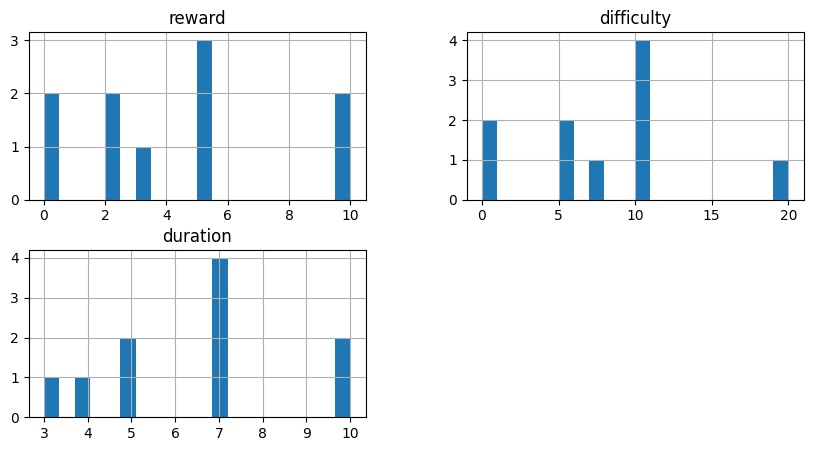

In [137]:
# 수치형 컬럼 분포 확인
portfolio.hist(figsize=(10,5), bins=20)

In [138]:
# 중복 행 확인
print(portfolio.duplicated().sum())

# PK(프로모션 id)의 중복값 확인
print(portfolio['id'].duplicated().sum())

0
0


In [139]:
# 리워드 분포 확인
portfolio['reward'].value_counts().sort_index()

,count
reward,
0,2
2,2
3,1
5,3
10,2


In [140]:
# 채널 분포 확인
portfolio['channels'].value_counts()

,count
channels,
"['web', 'email', 'mobile', 'social']",4
"['web', 'email', 'mobile']",3
"['email', 'mobile', 'social']",2
"['web', 'email']",1


In [141]:
# 프로모션 적용 기간 확인
portfolio['duration'].value_counts().sort_index()

,count
duration,
3,1
4,1
5,2
7,4
10,2


In [142]:
# 프로모션 유형 확인
portfolio['offer_type'].value_counts()

,count
offer_type,
bogo,4
discount,4
informational,2


In [143]:
# 프로모션 진행 수 확인
portfolio['id'].nunique()

10

In [144]:
# 프로모션 유형 별 평균 리워드, 지출 금액
portfolio.groupby('offer_type')[['reward', 'duration', 'difficulty']].mean()

,reward,duration,difficulty
offer_type,,,
bogo,7.5,6.0,7.50
discount,3.0,8.5,11.75
informational,0.0,3.5,0.00


In [145]:
# 프로모션 홍보 수단 별 평균 리워드, 지출 금액
portfolio.groupby('channels')[['reward', 'duration', 'difficulty']].mean()

,reward,duration,difficulty
channels,,,
"['email', 'mobile', 'social']",5.000000,5.00,5.0
"['web', 'email', 'mobile', 'social']",5.000000,6.75,8.0
"['web', 'email', 'mobile']",2.333333,6.00,5.0
"['web', 'email']",5.000000,10.00,20.0


## 2-2) profile (고객 정보)

In [146]:
print('\n', '='*60,'\n[데이터 구조 확인]')
display(profile.shape)

print('\n', '='*60,'\n[데이터 미리보기]\n')
display(profile.head(3))

print('\n', '='*60,'\n[기본 정보 요약]\n')
profile.info()

print('\n', '='*60,'\n[통계 정보 요약]\n')
display(profile.describe().T)


[데이터 구조 확인]


(17000, 5)


[데이터 미리보기]



,gender,age,id,became_member_on,income
0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN



[기본 정보 요약]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            14825 non-null  object 
 1   age               17000 non-null  int64  
 2   id                17000 non-null  object 
 3   became_member_on  17000 non-null  int64  
 4   income            14825 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 664.2+ KB

[통계 정보 요약]



,count,mean,std,min,25%,50%,75%,max
age,17000.0,6.253141e+01,26.738580,18.0,45.0,58.0,73.0,118.0
became_member_on,17000.0,2.016703e+07,11677.499961,20130729.0,20160526.0,20170802.0,20171230.0,20180726.0
income,14825.0,6.540499e+04,21598.299410,30000.0,49000.0,64000.0,80000.0,120000.0


In [147]:
# 결측치 관계 확인
profile.loc[profile['gender'].isna(), ['gender', 'age', 'income']]

,gender,age,income
0,NaN,118,NaN
2,NaN,118,NaN
4,NaN,118,NaN
6,NaN,118,NaN
7,NaN,118,NaN
...,...,...,...
16980,NaN,118,NaN
16982,NaN,118,NaN
16989,NaN,118,NaN
16991,NaN,118,NaN


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'became_member_on'}>],
       [<Axes: title={'center': 'income'}>, <Axes: >]], dtype=object)

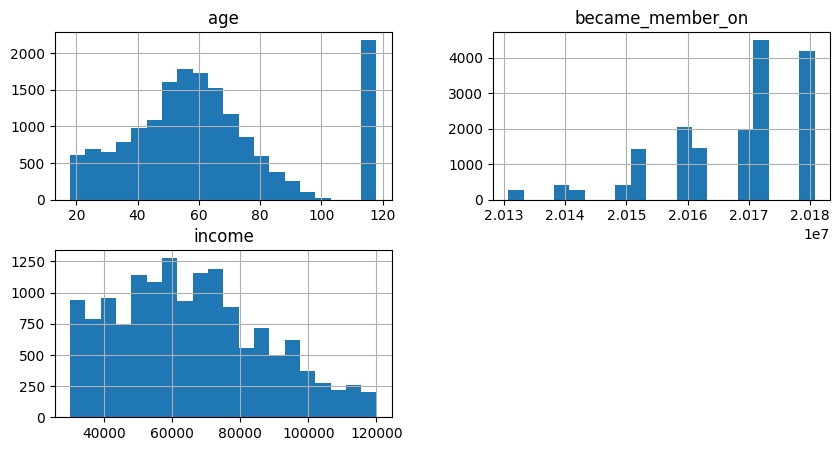

In [148]:
# 수치형 컬럼 분포 확인
profile.hist(figsize=(10,5), bins=20)

In [149]:
# 중복 행 확인
profile.duplicated().sum()

np.int64(0)

In [150]:
# PK(고객의 고유 id)의 중복값 확인
profile['id'].duplicated().sum()

np.int64(0)

In [151]:
# 성별 분포 확인
profile['gender'].value_counts()

,count
gender,
M,8484
F,6129
O,212


age
118    2175
58      408
53      372
51      363
59      359
       ... 
100      12
96        8
98        5
101       5
99        5
Name: count, Length: 85, dtype: int64


<Axes: >

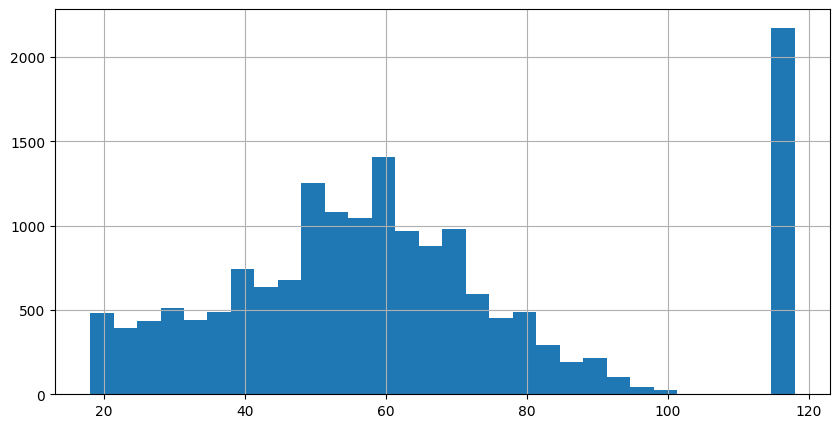

In [152]:
# 나이 분포 확인
print(profile['age'].value_counts())
profile['age'].hist(figsize=(10,5), bins=30)

In [153]:
# 나이 분포 확인 (고령자)
profile.loc[(profile['age'] >= 80) & (profile['age'] < 118), 'age']

,age
33,96
94,89
98,90
126,83
131,89
...,...
16914,87
16933,85
16938,89
16981,84


In [154]:
# 등록된 고객 수 확인
profile['id'].nunique()

17000

20130729 ~ 20180726


<Axes: >

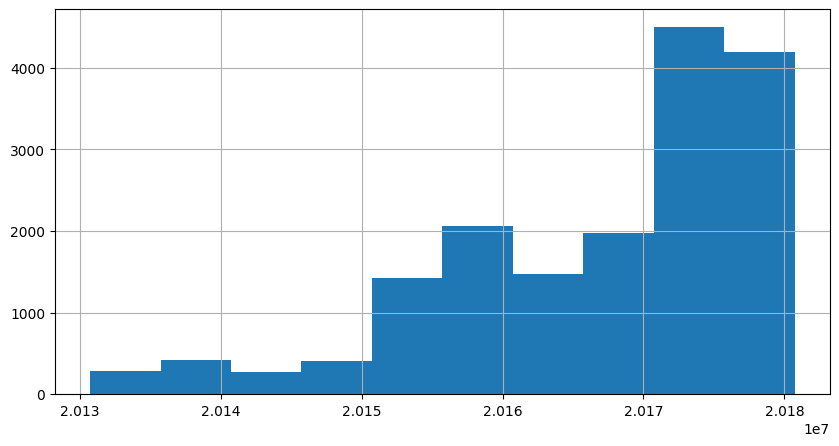

In [155]:
# 멤버십 가입일 기간 확인
member_on_min = profile['became_member_on'].min()
member_on_max = profile['became_member_on'].max()
print(f"{member_on_min} ~ {member_on_max}")

profile['became_member_on'].hist(figsize=(10,5), bins=10)

## 2-3) transcript (프로모션 참여 정보)

In [156]:
print('\n', '='*60,'\n[데이터 구조 확인]')
display(transcript.shape)

print('\n', '='*60,'\n[데이터 미리보기]\n')
display(transcript.head(3))

print('\n', '='*60,'\n[기본 정보 요약]\n')
transcript.info()

print('\n', '='*60,'\n[통계 정보 요약]\n')
display(transcript.describe().T)


[데이터 구조 확인]


(306534, 4)


[데이터 미리보기]



,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0



[기본 정보 요약]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306534 entries, 0 to 306533
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   person  306534 non-null  object
 1   event   306534 non-null  object
 2   value   306534 non-null  object
 3   time    306534 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 9.4+ MB

[통계 정보 요약]



,count,mean,std,min,25%,50%,75%,max
time,306534.0,366.38294,200.326314,0.0,186.0,408.0,528.0,714.0


In [157]:
# 중복 행 확인
print(transcript.duplicated().sum())
transcript.loc[transcript.duplicated(keep=False)].sort_values(by='person')

397


,person,event,value,time
218060,00d7c95f793a4212af44e632fdc1e431,offer completed,{'offer_id': '2906b810c7d4411798c6938adc9daaa5...,504
218058,00d7c95f793a4212af44e632fdc1e431,offer completed,{'offer_id': '2906b810c7d4411798c6938adc9daaa5...,504
220133,01925607d99c460996c281f17cdbb9e2,offer completed,{'offer_id': '4d5c57ea9a6940dd891ad53e9dbe8da0...,510
220134,01925607d99c460996c281f17cdbb9e2,offer completed,{'offer_id': '4d5c57ea9a6940dd891ad53e9dbe8da0...,510
171646,01956670cf414b309675aa73368b94a9,offer completed,{'offer_id': '2906b810c7d4411798c6938adc9daaa5...,420
...,...,...,...,...
274287,ff6a080134fc44dc9c7e7b5abcfbe849,offer completed,{'offer_id': 'ae264e3637204a6fb9bb56bc8210ddfd...,600
228666,ff80a43ecb34439491bd9ae1cff7c5fc,offer completed,{'offer_id': 'fafdcd668e3743c1bb461111dcafc2a4...,528
228665,ff80a43ecb34439491bd9ae1cff7c5fc,offer completed,{'offer_id': 'fafdcd668e3743c1bb461111dcafc2a4...,528
140993,ff95e0a9cdfd4030958762dadcb11e1a,offer completed,{'offer_id': '0b1e1539f2cc45b7b9fa7c272da2e1d7...,372


In [158]:
# 프로모션 참여자 확인 (중복 x)
transcript['person'].nunique()

17000

<Axes: >

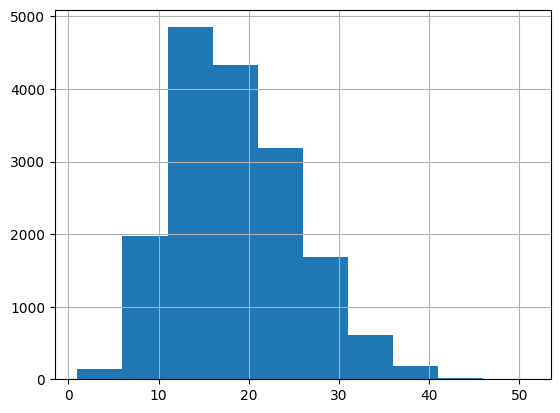

In [159]:
# 고객당 프로모션 참여 횟수 분포
transcript['person'].value_counts().hist()

In [160]:
# 이벤트 유형 확인
transcript['event'].value_counts()

,count
event,
transaction,138953
offer received,76277
offer viewed,57725
offer completed,33579


<Axes: >

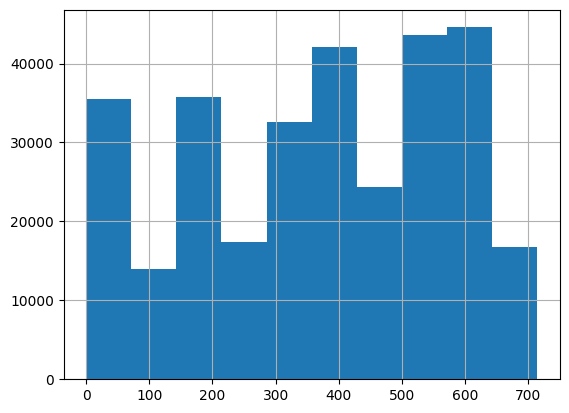

In [161]:
# time 분포 확인
transcript['time'].hist()

In [162]:
# time 유니크 값 확인
transcript['time'].unique()

array([  0,   6,  12,  18,  24,  30,  36,  42,  48,  54,  60,  66,  72,
        78,  84,  90,  96, 102, 108, 114, 120, 126, 132, 138, 144, 150,
       156, 162, 168, 174, 180, 186, 192, 198, 204, 210, 216, 222, 228,
       234, 240, 246, 252, 258, 264, 270, 276, 282, 288, 294, 300, 306,
       312, 318, 324, 330, 336, 342, 348, 354, 360, 366, 372, 378, 384,
       390, 396, 402, 408, 414, 420, 426, 432, 438, 444, 450, 456, 462,
       468, 474, 480, 486, 492, 498, 504, 510, 516, 522, 528, 534, 540,
       546, 552, 558, 564, 570, 576, 582, 588, 594, 600, 606, 612, 618,
       624, 630, 636, 642, 648, 654, 660, 666, 672, 678, 684, 690, 696,
       702, 708, 714])

---
# 3️⃣ 전처리 (병합 전)

## 3-1) portfolio (프로모션 정보)

In [163]:
# druation과 time 단위 통합: 일 단위 → 시간 단위 변경
portfolio['duration_hour'] = portfolio['duration']*24
portfolio[['duration', 'duration_hour']].head(3)

,duration,duration_hour
0,7,168
1,5,120
2,4,96


## 3-2) profile (고객 정보)

In [164]:
# 세대별 그룹화 (계산 시점: 2018년)
def age_group(age):
    if age >= 118:
        return 'NONE'
    elif age >= 73:
        return '사일런트 세대'
    elif age >= 54:
        return '베이비붐 세대'
    elif age >= 38:
        return 'X세대'
    elif age >= 22:
        return '밀레니얼 세대'
    else:
        return 'Z세대'

profile['generation'] = profile['age'].apply(age_group)
profile.head(3)

,gender,age,id,became_member_on,income,generation
0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN,NONE
1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0,베이비붐 세대
2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN,NONE


In [165]:
# log 변환 (정규성 확보)
profile['log_income'] = np.log(profile['income'])
profile[['income', 'log_income']].head(3)

,income,log_income
0,NaN,NaN
1,112000.0,11.626254
2,NaN,NaN


In [166]:
# 문자열 → 날짜열 변환
profile['became_member_on'] = pd.to_datetime(profile['became_member_on'], format='%Y%m%d')
profile['became_member_on'].head(3)

,became_member_on
0,2017-02-12
1,2017-07-15
2,2018-07-12


## 3-2) transcript (프로모션 참여 정보)

In [167]:
# 변환: 문자열 → 딕셔너리
transcript['value'] = transcript['value'].apply(ast.literal_eval)

# json_normalize: 딕셔너리 → 컬럼화
trans_value = pd.json_normalize(transcript['value'])
trans_value

# 원본 데이터프레임과 병합
transcript = pd.concat([transcript, trans_value], axis=1)

# 'offer id'와 'offer_id' 컬럼 병합
if 'offer id' in transcript.columns and 'offer_id' in transcript.columns:
    transcript['offer_id'] = transcript['offer_id'].fillna(transcript['offer id'])
    transcript.drop('offer id', axis=1, inplace=True)

# 숫자 결측값 대체: 0으로
transcript['amount']=transcript['amount'].fillna(0)
transcript['reward']=transcript['reward'].fillna(0)

# value 컬럼 제거
transcript.drop('value', axis=1, inplace=True)

In [168]:
# 중복 제거
print(f"중복 제거 전 행 개수: {len(transcript)}")
print(f"중복 개수: {transcript.duplicated().sum()}")

transcript.drop_duplicates(inplace=True)

print(f"중복 제거 후 행 개수: {len(transcript)}")

# index 생성:
transcript.reset_index(drop=True,inplace=True)
transcript.reset_index(inplace=True)
transcript

중복 제거 전 행 개수: 306534
중복 개수: 397
중복 제거 후 행 개수: 306137


,index,person,event,time,amount,offer_id,reward
0,0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,0.00,9b98b8c7a33c4b65b9aebfe6a799e6d9,0.0
1,1,a03223e636434f42ac4c3df47e8bac43,offer received,0,0.00,0b1e1539f2cc45b7b9fa7c272da2e1d7,0.0
2,2,e2127556f4f64592b11af22de27a7932,offer received,0,0.00,2906b810c7d4411798c6938adc9daaa5,0.0
3,3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,0.00,fafdcd668e3743c1bb461111dcafc2a4,0.0
4,4,68617ca6246f4fbc85e91a2a49552598,offer received,0,0.00,4d5c57ea9a6940dd891ad53e9dbe8da0,0.0
...,...,...,...,...,...,...,...
306132,306132,b3a1272bc9904337b331bf348c3e8c17,transaction,714,1.59,NaN,0.0
306133,306133,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,714,9.53,NaN,0.0
306134,306134,a00058cf10334a308c68e7631c529907,transaction,714,3.61,NaN,0.0
306135,306135,76ddbd6576844afe811f1a3c0fbb5bec,transaction,714,3.53,NaN,0.0


In [169]:
print(portfolio.shape)
print(profile.shape)
print(transcript.shape)

(10, 7)
(17000, 7)
(306137, 7)


---
# 4️⃣ 분석용 테이블 병합

In [240]:
starbucks = pd.merge(transcript, portfolio,  how='left', left_on='offer_id', right_on='id', suffixes=('_t','_p'))
starbucks = pd.merge(starbucks, profile, how='inner', left_on='person', right_on='id')

분석용 테이블 복사

In [242]:
starbucks_cp = starbucks.copy()

---
# 5️⃣ 전처리 (병합 후)

In [244]:
# 불필요한 컬럼 삭제
starbucks_cp.drop(columns=['reward_p', 'duration', 'id_x', 'id_y'], inplace=True)

# 컬럼 순서 변경
starbucks_cp = starbucks_cp[[
    # 고객 관련
    'person', 'gender', 'age', 'generation', 'income', 'log_income', 'became_member_on',

    # 프로모션 관련
    'offer_id', 'offer_type', 'difficulty', 'reward_t', 'channels', 'duration_hour',

    # 이벤트 관련
    'event', 'time', 'amount'
]]

# 컬럼명 변경
starbucks_cp.rename(columns={'reward_t': 'reward'}, inplace=True)

# 파생 변수: 일, 주 단위
starbucks_cp['day'] = (starbucks_cp['time'] // 24) +1
starbucks_cp['week'] = (starbucks_cp['day'] // 7) + 1

# 타입 변경
starbucks_cp['income'] = pd.to_numeric(starbucks_cp['income'], errors='coerce')

starbucks_cp.head(3)

,person,gender,age,generation,income,log_income,became_member_on,offer_id,offer_type,difficulty,reward,channels,duration_hour,event,time,amount,day,week
0,78afa995795e4d85b5d9ceeca43f5fef,F,75.0,사일런트 세대,100000.0,11.512925,2017-05-09,9b98b8c7a33c4b65b9aebfe6a799e6d9,bogo,5.0,0.0,"['web', 'email', 'mobile']",168.0,offer received,0,0.0,1,1
1,a03223e636434f42ac4c3df47e8bac43,NONE,NaN,NONE,NaN,NaN,2017-08-04,0b1e1539f2cc45b7b9fa7c272da2e1d7,discount,20.0,0.0,"['web', 'email']",240.0,offer received,0,0.0,1,1
2,e2127556f4f64592b11af22de27a7932,M,68.0,베이비붐 세대,70000.0,11.156251,2018-04-26,2906b810c7d4411798c6938adc9daaa5,discount,10.0,0.0,"['web', 'email', 'mobile']",168.0,offer received,0,0.0,1,1


In [245]:
# 결측값 대체 → NONE
starbucks_cp['gender'] = starbucks_cp['gender'].fillna('NONE')
starbucks_cp['income'] = starbucks_cp['income'].fillna('NONE')
print(f"성별 결측값: {starbucks_cp['gender'].isna().sum()}")
print(f"소득 결측값: {starbucks_cp['income'].isna().sum()}")

# 이상값 대체 → NONE
starbucks_cp.loc[starbucks_cp['age'] == 118, 'age'] = np.nan

starbucks_cp.head(3)

성별 결측값: 0
소득 결측값: 0


,person,gender,age,generation,income,log_income,became_member_on,offer_id,offer_type,difficulty,reward,channels,duration_hour,event,time,amount,day,week
0,78afa995795e4d85b5d9ceeca43f5fef,F,75.0,사일런트 세대,100000.0,11.512925,2017-05-09,9b98b8c7a33c4b65b9aebfe6a799e6d9,bogo,5.0,0.0,"['web', 'email', 'mobile']",168.0,offer received,0,0.0,1,1
1,a03223e636434f42ac4c3df47e8bac43,NONE,NaN,NONE,NONE,NaN,2017-08-04,0b1e1539f2cc45b7b9fa7c272da2e1d7,discount,20.0,0.0,"['web', 'email']",240.0,offer received,0,0.0,1,1
2,e2127556f4f64592b11af22de27a7932,M,68.0,베이비붐 세대,70000.0,11.156251,2018-04-26,2906b810c7d4411798c6938adc9daaa5,discount,10.0,0.0,"['web', 'email', 'mobile']",168.0,offer received,0,0.0,1,1


---
# 6️⃣ 분석

## 6-1) 통계 분석 함수 선언

### 6-1-1) 정규성 검정

검정의 기본 가정을 충족하는지 확인하기 위해: 데이터가 정규분포를 따르는지 확인

In [174]:
def norm_test(data, name='데이터'):
    # 표본의 크기
    n = len(data)
    print(f"정규성 검정: {name}")
    print(f"n: {n}")

    # 왜도와 첨도
    skew = stats.skew(data)
    kurt = stats.kurtosis(data, fisher=True)  # 정규분포의 첨도를 0으로 설정

    # 정규성 확인
    if n < 30:  # 샤피로 검정
        stat, p = shapiro(data)
        print(f"shapiro검정 p_value: {p:.4f}")
        if p > 0.05:
            print(f"정규성을 만족한다고 볼 수 있음 (귀무가설 기각 불가)")
        else:
            print("정규성을 만족하지 않음 (귀무가설 기각)")
            print("비모수 검정 고려")

    else:
        if abs(skew) < 2 and abs(kurt) < 7:  # CLT가 작동할 수 있는 분포인지 왜도와 첨도 확인
            print(f"정규성 가정 가능 (표본이 충분히 크고 왜도/첨도 기준이 충족)")
            print(f"|왜도|: {skew:.3f}")
            print(f"|첨도|: {kurt:.3f}")
        else:
            stat, p = shapiro(data)  # 샤피로 검정
            print(f"shapiro검정 p_value: {p:.4f}")
            if p > 0.05:
                print(f"정규성을 만족한다고 볼 수 있음 (귀무가설 기각 불가)")
            else:
                print("정규성을 만족하지 않음 (귀무가설 기각)")
                print("비모수 검정 고려")

### 6-1-2) 등분산성 검정

검정의 기본 가정을 충족하는지 확인하기 위해: 두 데이터의 분산이 같은지 확인
- 이표본 t검정(독립된 두 집단)
- ANOVA (세 집단 이상)

In [175]:
def var_test(*groups):
    print(f"등분산성 검정 (levene)")

    # 등분산성 확인
    stat, p = levene(*groups)
    print(f"levene검정 p_value: {p:.4f}")
    if p > 0.05:
        print(f"등분산성을 만족한다고 볼 수 있음 (귀무가설 기각 불가)")
        print(f"t-test 가능")
    else:
        print("등분산성을 만족하지 않음 (귀무가설 기각)")
        print(f"Welch 검정 권장")

### 6-1-3)  cramer's v 계산

두 변수 간의 연관성 강도를 측정

In [176]:
def cramers_v(data1, data2):
    # 교차표 생성
    ct = pd.crosstab(data1, data2)

    # 카이제곱 검정
    chi2, p, dof, expected = chi2_contingency(ct)

    # cramer's v 계산
    n = ct.sum().sum()
    r, c = ct.shape
    v = np.sqrt(chi2 / ( n * min(r-1, c-1)))

    print('='*30)
    print(f"cramers_v 계산")
    print('='*30)
    print(f"카이제곱 통계량: {chi2:.3f}")
    print('-'*30)
    print(f"p-value: {p:.3f}")
    if p < 0.05:
        print("귀무가설 기각")
    else:
        print("귀무가설 채택")
    print('-'*30)
    print(f"cramers v: {v:.3f}")

    # 해석
    if v < 0.1:
        strength = "약한 연관"
    elif v < 0.3:
        strength = "중간 연관"
    else:
        strength = "강한 연관 → 변수 후보로 유지"
    print(f"연관 관계: {strength}")
    print('='*30)

    return v

## 6-2) 임혜윤(amount 파생변수 생성)

In [177]:
# 1. 'offer completed'만
completed_df = (
    transcript.loc[transcript['event'].eq('offer completed'), ['person', 'time', 'offer_id']]
    #.drop_duplicates(subset=['person','time'])      # 같은 시각 중복
)

# 2. 'transaction'만
transaction_df = (
    transcript.loc[transcript['event'].eq('transaction'), ['index','person','time','amount']].copy()
)

# 3. (person x time) 기준으로 offer_id 붙이기
transaction_df_matched = (
    transaction_df.merge(
        completed_df,
        on=['person','time'],
        how='inner').rename(columns={'offer_id':'matched_offer_id'})
)

# 4. offer_id 기준으로 reward 붙이기
transaction_df_matched = pd.merge(
    transaction_df_matched,
    portfolio[['id','reward']],
    left_on='matched_offer_id',
    right_on='id').drop(columns=['id'])

# 5. (person x time) 기준으로 reward의 합
reward_sum = transaction_df_matched.groupby(['person','time'])['reward'].sum()

# 6. (person x time) 기준으로 reward의 합 붙이기
transaction_df_matched = pd.merge(
    transaction_df_matched,
    reward_sum,
    left_on=['person','time'],
    right_index=True,
    suffixes=['','_sum']
)

# 7. reward에 따른 weight
transaction_df_matched['weight'] = transaction_df_matched['reward']/transaction_df_matched['reward_sum']

# 8. weight에 따른 결제금액(weight_amount)
transaction_df_matched['weight_amount'] = transaction_df_matched['amount']*transaction_df_matched['weight']

# 9. 필요한 컬럼만 추출
df = transaction_df_matched[['index','matched_offer_id', 'reward_sum', 'weight_amount']]

# 10. index 기준으로 붙이기
transcript_merged = pd.merge(transcript,
                             df,
                             how='left',
                             on='index')

# 11. 빈 셀에 값 넣기
# weight_amount 빈 칸에 amount 넣기
transcript_merged['weight_amount'] = transcript_merged['weight_amount'].combine_first(transcript_merged['amount'])

# 12. offer_id 빈 칸에 matched_offer_id 넣기
transcript_merged['offer_id'] = transcript_merged['offer_id'].combine_first(transcript_merged['matched_offer_id'])
transcript_merged.head()

# # 13. 불필요한 컬럼 삭제
# transcript_merged.drop(columns=['reward_sum', 'matched_offer_id', 'amount'], inplace=True)

# 14. 파생 변수 생성: day, week
transcript_merged['day'] = (transcript_merged['time'] // 24) + 1
transcript_merged['week'] = (transcript_merged['day'] // 7) + 1

## 6-3) 이희창

### 6-3-1) 참여율 확인: 신규 vs 기존

- 신규 고객: 2018년 7월 가입 고객 (7,076명)

- 기존 고객: 2018년 7월 이전 가입 고객 (299,061명)

In [178]:
# datetime으로 계산시 에러가 발생하여 문자열로 변환
starbucks_cp['became_member_on'] = starbucks_cp['became_member_on'].astype(str)

# 신규 고객 참여율 계산: offer completed / offer received
new_customer = starbucks_cp.loc[starbucks_cp['became_member_on'].str.contains("2018-07")]
new_customer_rate = (new_customer['event'].value_counts()['offer completed'] /
                     new_customer['event'].value_counts()['offer received']) * 100
print(f"신규 고객 참여율: {new_customer_rate:.2f}%")

# 기존 고객 참여율 계산: offer completed / offer received
existing_customer = starbucks_cp.loc[~starbucks_cp['became_member_on'].str.contains("2018-07")]
existing_customer_rate = (existing_customer['event'].value_counts()['offer completed'] /
                          existing_customer['event'].value_counts()['offer received']) *100
print(f"기존 고객 참여율: {existing_customer_rate:.2f}%")

신규 고객 참여율: 26.90%
기존 고객 참여율: 44.01%


Two-Proportion Z-test: 두 집단의 비율 차이 검정
- 귀무가설: 기존 고객과 신규 고객의 참여율의 차이가 없다.

- 대립가설: 기존 고객과 신규 고객의 참여율의 차이가 있다.

In [179]:
from statsmodels.stats.proportion import proportions_ztest

diff_completed = [new_customer['event'].value_counts()['offer completed'],
                  existing_customer['event'].value_counts()['offer completed']]

diff_received = [new_customer['event'].value_counts()['offer received'],
                 existing_customer['event'].value_counts()['offer received']]

stat, p = proportions_ztest(diff_completed, diff_received)
if p < 0.05:
    print("귀무가설 기각")
else:
    print("귀무가설 채택")
p

귀무가설 기각


np.float64(1.382569697442324e-58)

## 6-4 함동호

### 6-4-1) 고객 생존 분석

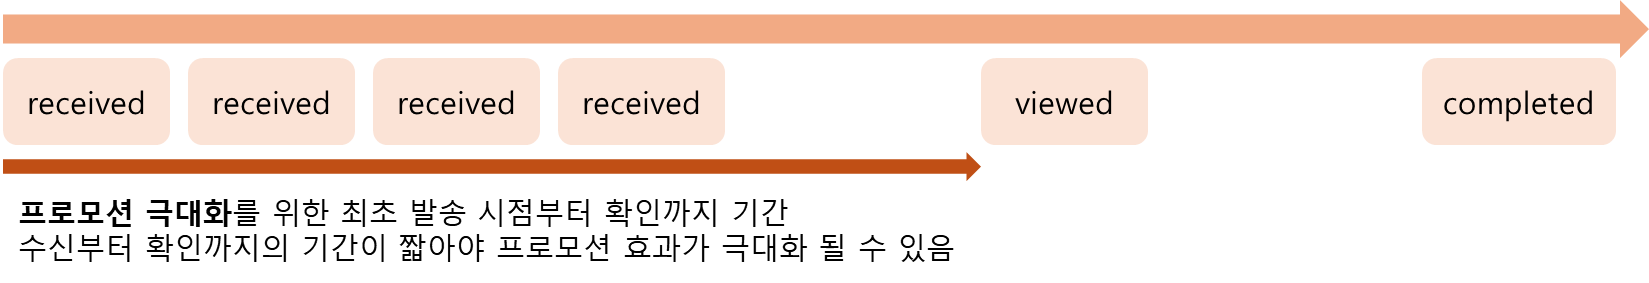

- 프로모션 효과 극대화를 위해서는 time 정보로 고객이 얼마나 빠르게 프로모션에 참여했는지 알아야 함
- 첫 수신 시점에 가장 빠르게 완료까지 달성하는 시간(min)이 실제 고객의 관심도와 반응 속도를 나타냄
- 마지막 수신 기점으로 하면 실제 발송부터 완료까지 달성 시간을 정확히 측정할 수 없음. 고객의 반응 신선도를 놓칠 수 있음

*피벗 생성 및 전처리*

데이터 제거해야 하는 경우
- 시간이 물리적 순서가 불가능한 경우(recieved -> viewed -> completed가 아닌 경우)
- received가 없는 경우

데이터 보존해야 하는 경우
- received -> completed: 정보 전달인 informational 프로모션일 수 있음

In [247]:
# 프로모션 퍼널 분석을 위한 offer 테이블 생성
# 프로모션 관점에서 고객 특성을 분석하기 위해서 transaction을 제외하고, starbucks에서 offer 만 분리
starbucks_offer = starbucks_cp[(starbucks['event'] == 'offer received') | (starbucks_cp['event'] == 'offer viewed') | (starbucks_cp['event'] == 'offer completed')]

In [248]:
# 전체 offer 대비 조회율과 완료율 계산

total_received_count = len(starbucks_offer[starbucks_offer['event'] == 'offer received'])
total_viewed_count = len(starbucks_offer[starbucks_offer['event'] == 'offer viewed'])
total_completed_count = len(starbucks_offer[starbucks_offer['event'] == 'offer completed'])

view_rate = total_viewed_count / total_received_count * 100
completion_rate = total_completed_count / total_received_count * 100

print(f"오퍼 조회율 (건수 기준): {view_rate:.2f}%")
print(f"오퍼 완료율 (건수 기준): {completion_rate:.2f}%")

오퍼 조회율 (건수 기준): 75.68%
오퍼 완료율 (건수 기준): 43.50%


In [182]:
customer_offer_journey = starbucks_offer.pivot_table(
    index=['person', 'offer_id', 'offer_type', 'gender', 'age',	'became_member_on', 'income',	'generation', 'channels', 'log_income'],
    columns='event',
    values='time',
    aggfunc='min'  # 첫 발생 시간, 어떤 고객이 여러 번 조회할 수도 있음.
).reset_index()

# 시간 상 순서가 일치하지 않음
customer_offer_journey.head(3)

event,person,offer_id,offer_type,gender,age,became_member_on,income,generation,channels,log_income,offer completed,offer received,offer viewed
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,discount,M,33.0,2017-04-21,72000.0,밀레니얼 세대,"['web', 'email', 'mobile']",11.184421,576.0,576.0,NaN
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,informational,M,33.0,2017-04-21,72000.0,밀레니얼 세대,"['web', 'email', 'mobile']",11.184421,NaN,336.0,372.0
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,informational,M,33.0,2017-04-21,72000.0,밀레니얼 세대,"['email', 'mobile', 'social']",11.184421,NaN,168.0,192.0


In [250]:
# 정보성 프로모션 중에서 오직 수신만 한 데이터들이 존재 -> 삭제 X
customer_offer_journey[(customer_offer_journey['offer_type']=='informational') & (customer_offer_journey['offer viewed'].isna())].isna().sum()

,0
event,
person,0
offer_id,0
offer_type,0
gender,0
age,0
became_member_on,0
income,0
generation,0
channels,0


In [251]:
# 완료 이후에 다시 조회한 프로모션은 고객 여정 분석에 적합하지 않아 삭제
drop_unnormal_time_rows = (customer_offer_journey['offer_type'] != 'informational') & (customer_offer_journey['offer viewed'] > customer_offer_journey['offer completed'])
customer_offer_journey_cleaned = customer_offer_journey[~drop_unnormal_time_rows]

customer_offer_journey_cleaned.shape

(51559, 13)

In [252]:
# 정제 데이터셋 확인
customer_offer_journey_cleaned.head(3)

event,person,offer_id,offer_type,gender,age,became_member_on,income,generation,channels,log_income,offer completed,offer received,offer viewed
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,discount,M,33.0,2017-04-21,72000.0,밀레니얼 세대,"['web', 'email', 'mobile']",11.184421,576.0,576.0,NaN
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,informational,M,33.0,2017-04-21,72000.0,밀레니얼 세대,"['web', 'email', 'mobile']",11.184421,NaN,336.0,372.0
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,informational,M,33.0,2017-04-21,72000.0,밀레니얼 세대,"['email', 'mobile', 'social']",11.184421,NaN,168.0,192.0


In [253]:
# 반응률, 반응 속도 분석
# 반응 분석을 위해서는 스타벅스에서 설계한 received -> viewed -> completed 루트를 따르는 정상적인 프로모션만 필요함. NaN 값들이 있으면 제외.
customer_offer_journey_normal = customer_offer_journey_cleaned.dropna()

customer_offer_journey_normal['time_to_view'] = customer_offer_journey_normal['offer viewed'] - customer_offer_journey_normal['offer received']
customer_offer_journey_normal['time_to_complete'] = customer_offer_journey_normal['offer completed'] - customer_offer_journey_normal['offer received']
customer_offer_journey_normal['view_to_complete'] = customer_offer_journey_normal['offer completed'] - customer_offer_journey_normal['offer viewed']

/tmp/ipython-input-3965478514.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  customer_offer_journey_normal['time_to_view'] = customer_offer_journey_normal['offer viewed'] - customer_offer_journey_normal['offer received']
/tmp/ipython-input-3965478514.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  customer_offer_journey_normal['time_to_complete'] = customer_offer_journey_normal['offer completed'] - customer_offer_journey_normal['offer received']
/tmp/ipython-input-3965478514.py:7: SettingWithCopyWa

In [187]:
# 반응 속도 분포 확인을 위해 속도 구간 분리
customer_offer_journey_normal['reaction_type'] = pd.cut(
    customer_offer_journey_normal['time_to_view'],
    bins = [0, 24, 72, 168, float('inf')],
    labels = ['instant', 'fast', 'normal', 'slow'] # 즉시 반응, 빠른 반응, 일반 반응, 느린 반응
)

customer_offer_journey_normal.head(3)

/tmp/ipython-input-36842136.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  customer_offer_journey_normal['reaction_type'] = pd.cut(


event,person,offer_id,offer_type,gender,age,became_member_on,income,generation,channels,log_income,offer completed,offer received,offer viewed,time_to_view,time_to_complete,view_to_complete,reaction_type
5,0011e0d4e6b944f998e987f904e8c1e5,0b1e1539f2cc45b7b9fa7c272da2e1d7,discount,O,40.0,2018-01-09,57000.0,X세대,"['web', 'email']",10.950807,576.0,408.0,432.0,24.0,168.0,144.0,instant
6,0011e0d4e6b944f998e987f904e8c1e5,2298d6c36e964ae4a3e7e9706d1fb8c2,discount,O,40.0,2018-01-09,57000.0,X세대,"['web', 'email', 'mobile', 'social']",10.950807,252.0,168.0,186.0,18.0,84.0,66.0,instant
9,0011e0d4e6b944f998e987f904e8c1e5,9b98b8c7a33c4b65b9aebfe6a799e6d9,bogo,O,40.0,2018-01-09,57000.0,X세대,"['web', 'email', 'mobile']",10.950807,576.0,504.0,516.0,12.0,72.0,60.0,instant


/tmp/ipython-input-1172937116.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=reaction_df['reaction_type'], y=reaction_df['count'], palette='plasma')


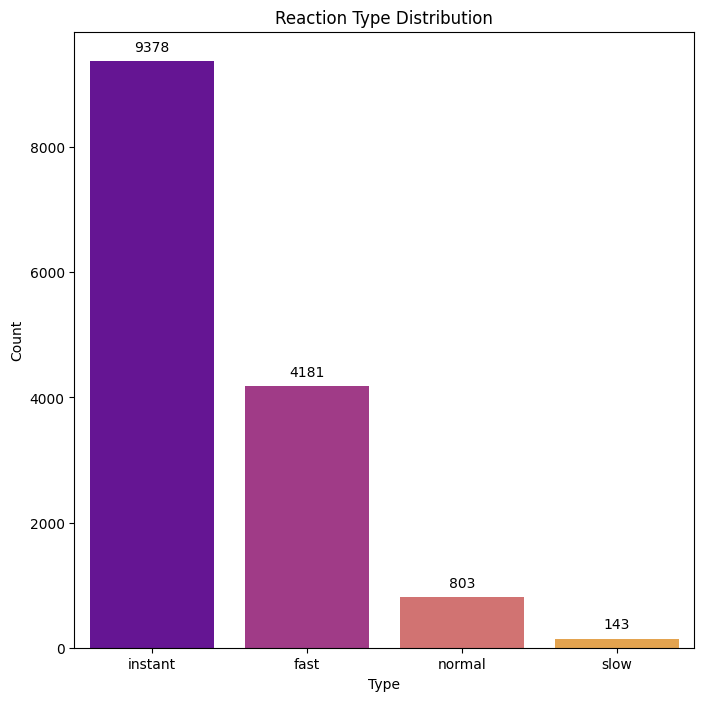

In [188]:
# 반응 유형 분포 확인을 위해 반응 분포 횟수가 저장된 데이터셋 생성
reaction_df = customer_offer_journey_normal['reaction_type'].value_counts().reset_index()

plt.figure(figsize=(8, 8))
ax = sns.barplot(x=reaction_df['reaction_type'], y=reaction_df['count'], palette='plasma')

for p in ax.patches:
    # p.get_x() : 바의 왼쪽 x 좌표
    # p.get_width() : 바의 너비
    # p.get_height() : 바의 높이 (즉, count 값)
    # 텍스트의 x 위치: 바의 중앙 (p.get_x() + p.get_width() / 2.)
    # 텍스트의 y 위치: 바의 높이 바로 위 (p.get_height())
    ax.annotate(f'{int(p.get_height())}', # 표시할 텍스트 (정수형으로 변환)
                (p.get_x() + p.get_width() / 2., p.get_height()), # 텍스트 위치
                ha='center',        # 수평 정렬 (가운데)
                va='bottom',        # 수직 정렬 (바 위에)
                xytext=(0, 5),      # 텍스트를 바 위로 살짝 올리기 위한 오프셋 (x, y)
                textcoords='offset points', # xytext가 오프셋을 의미하도록 설정
                fontsize=10,        # 글자 크기
                color='black')      # 글자 색상

plt.title('Reaction Type Distribution')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

In [189]:
# 어떤 고객이 생존했는지 확인하기 위해 각 시간 구간 별 속도 중앙값 측정
# 확인 후 완료까지의 시간, 전체 완료 시간은 모두 bogo가 짧음 -> bogo에 민감하게 반응하는 고객들이 있음
median_response = customer_offer_journey_normal.groupby('offer_type').agg({
    'time_to_view': 'median',
    'view_to_complete': 'median',
    'time_to_complete': 'median'
}).round(2)

median_response

event,time_to_view,view_to_complete,time_to_complete
offer_type,,,
bogo,12.0,30.0,48.0
discount,12.0,36.0,66.0


In [190]:
# 성별 반응 속도 차이 의미 없음
customer_offer_journey_normal.groupby('gender')['time_to_view'].median()

,time_to_view
gender,
F,12.0
M,12.0
O,12.0


In [191]:
# 세대 별 반응 속도 차이 의미 없음
customer_offer_journey_normal.groupby('generation')['time_to_view'].median()

,time_to_view
generation,
X세대,12.0
Z세대,18.0
밀레니얼 세대,12.0
베이비붐 세대,12.0
사일런트 세대,12.0


In [192]:
# 소득 구간 별 반응 속도 차이 없음
customer_offer_journey_normal['income_group'] = pd.cut(
    customer_offer_journey_normal['income'],
    bins=[0, 40000, 60000, 80000, 100000, 200000],
    labels=['low', 'mid-low', 'mid', 'mid-high', 'high']
)

customer_offer_journey_normal.groupby('income_group')['time_to_view'].median()

/tmp/ipython-input-3319889729.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  customer_offer_journey_normal['income_group'] = pd.cut(
/tmp/ipython-input-3319889729.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  customer_offer_journey_normal.groupby('income_group')['time_to_view'].median()


,time_to_view
income_group,
low,12.0
mid-low,12.0
mid,12.0
mid-high,12.0
high,12.0


In [193]:
# 반응 속도에 따른 고객 특성 차이 확인을 위해 instant, fast는 긍정적 반응 고객, normal과 slow는 부정적 반응 고객으로 분리

positive_reaction = customer_offer_journey_normal[(customer_offer_journey_normal['reaction_type']=='instant') | (customer_offer_journey_normal['reaction_type']=='fast')]
negative_reaction = customer_offer_journey_normal[(customer_offer_journey_normal['reaction_type']=='normal') | (customer_offer_journey_normal['reaction_type']=='slow')]

In [194]:
# 다른 특성에 비해 채널이 매우 유의미한 p-value와 검정 통계량을 보임

positive_customer = positive_reaction['channels'].value_counts()
negative_customer = negative_reaction['channels'].value_counts()

# 교차표를 만듭니다.
contingency_table = pd.DataFrame({
    'Positive Customer': positive_customer,
    'Negative Customer': negative_customer
})

# 카이제곱 검정을 실행합니다.
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-squared 검정통계량: {chi2:.2f}")
print(f"P-value: {p:.4f}")

# 결과 해석
alpha = 0.01
if p < alpha:
    print("통계적으로 유의하여 귀무가설을 기각합니다.")
else:
    print("통계적으로 유의하지 않아 귀무가설을 채택합니다.")

Chi-squared 검정통계량: 472.57
P-value: 0.0000
통계적으로 유의하여 귀무가설을 기각합니다.


/tmp/ipython-input-3368501423.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=positive_customer.index, y=positive_customer.values, palette='plasma', ax=axes[0])
/tmp/ipython-input-3368501423.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=negative_customer.index, y=negative_customer.values, palette='plasma', ax=axes[1])


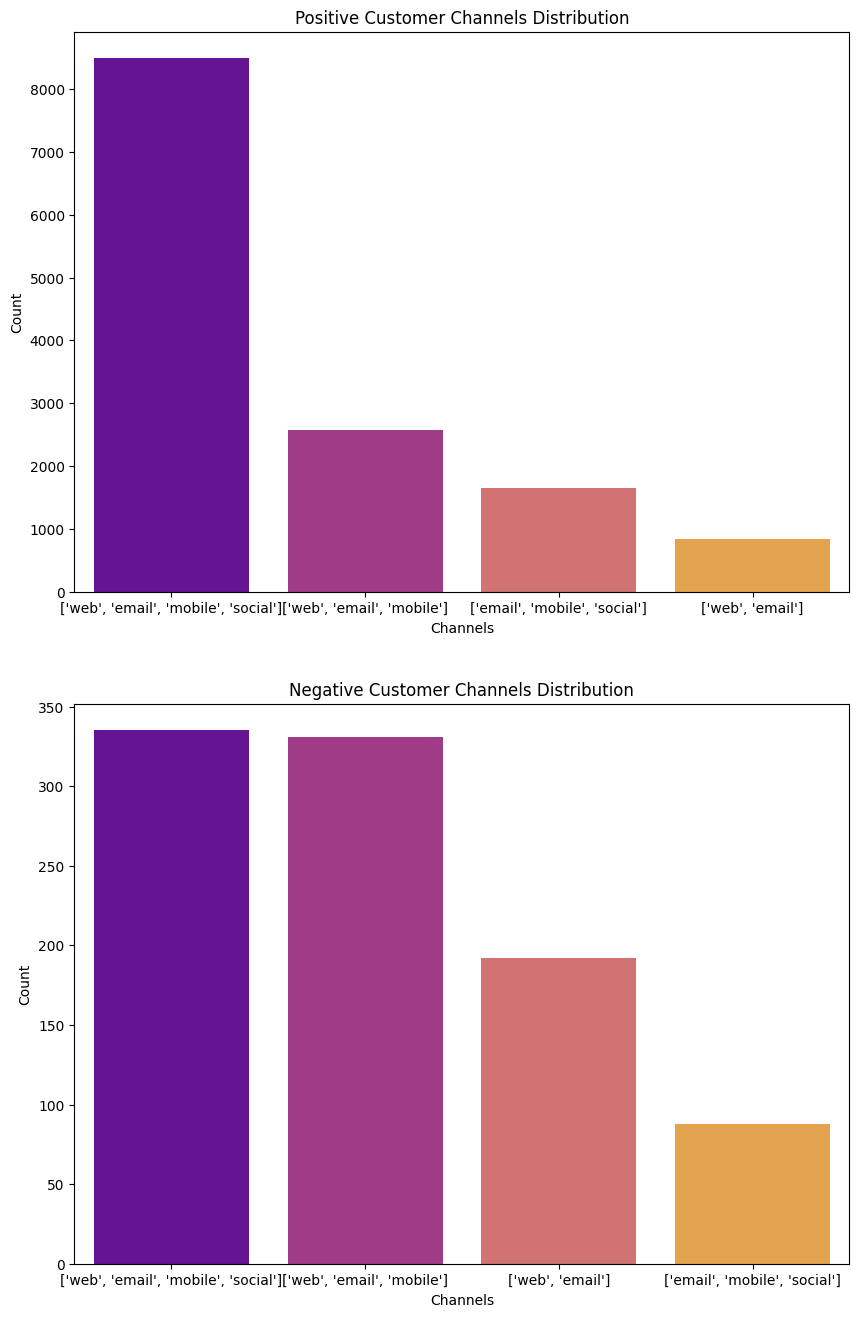

In [195]:
# 반응 속도 고객군 간 채널 분포를 비교

fig, axes = plt.subplots(2, 1, figsize=(10, 16))

sns.barplot(x=positive_customer.index, y=positive_customer.values, palette='plasma', ax=axes[0])
axes[0].set_title('Positive Customer Channels Distribution')
axes[0].set_xlabel('Channels')
axes[0].set_ylabel('Count')

sns.barplot(x=negative_customer.index, y=negative_customer.values, palette='plasma', ax=axes[1])
axes[1].set_title("Negative Customer Channels Distribution")
axes[1].set_xlabel('Channels')
axes[1].set_ylabel('Count')

plt.show()

### 6-4-1) 충성 고객과 이탈 고객 분석

충성 고객

- received -> completed 비율이 50% 이상인 고객

In [196]:
# 다른 컬럼은 완료율, 조회율 계산 시 필요 없으니 person과 offer_id로 그룹핑한 테이블을 사용
# 각 회원마다 offer 진행 정도에 따라 여러 offer id를 할당 받을 수 있습니다. 따라서 이런 offer id를 진행 정도에 따라 분리할 필요 존재
# offer id 별 수신, 조회, 완료를 1과 0으로 할당

offer_status = starbucks_offer.pivot_table(
    index=['person', 'offer_id', 'offer_type', 'gender', 'age',	'became_member_on', 'income',	'generation', 'channels'],
    columns='event',
    aggfunc='size', # 각 이벤트가 발생하면 1, 아니면 NaN (fill_value로 0으로 채울 수 있음)
    fill_value=0
).reset_index()

offer_status.head(3)

event,person,offer_id,offer_type,gender,age,became_member_on,income,generation,channels,offer completed,offer received,offer viewed
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,discount,M,33.0,2017-04-21,72000.0,밀레니얼 세대,"['web', 'email', 'mobile']",1,1,0
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,informational,M,33.0,2017-04-21,72000.0,밀레니얼 세대,"['web', 'email', 'mobile']",0,1,1
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,informational,M,33.0,2017-04-21,72000.0,밀레니얼 세대,"['email', 'mobile', 'social']",0,1,1


In [197]:
# 시간 피벗 테이블에서 정의한 drop_unnormal_time_rows를 활용해서 동일하게 제거하기

offer_status_cleaned = offer_status[~drop_unnormal_time_rows]
offer_status_cleaned.shape

(51559, 12)

In [198]:
# 충성 고객 찾기
# 먼저 확인하지 않아도 오퍼를 받은 이후 완료한 고객을 선별합니다.
loyal_customer = offer_status[(offer_status['offer viewed'] == 0) & (offer_status['offer completed'] != 0)]

# 비율을 구하기 위해 고객 별로 집계합니다.
customer_completion_rate = offer_status.groupby('person').agg({
    'offer received': 'sum',
    'offer completed': 'sum'
}).reset_index()

# 집계 이후에 비율을 구합니다.
customer_completion_rate['completion_rate'] = (
    customer_completion_rate['offer completed'] /
    customer_completion_rate['offer received']
)

# 50% 이상인 고객을 customer_completion_rate를 기준으로 필터링 합니다.
loyal_customers_id_filter = customer_completion_rate[
    customer_completion_rate['completion_rate'] >= 0.5
]

# loyal_customer에서 해당 되는 아이디만 필터링 합니다.
unique_id = loyal_customers_id_filter['person'].unique() # 먼저 고유한 id를 찾습니다.
final_loyal_customer = loyal_customer[loyal_customer['person'].isin(unique_id)] # unique_id가 있는 행만 남깁니다.
final_loyal_customer.head(3)

event,person,offer_id,offer_type,gender,age,became_member_on,income,generation,channels,offer completed,offer received,offer viewed
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,discount,M,33.0,2017-04-21,72000.0,밀레니얼 세대,"['web', 'email', 'mobile']",1,1,0
18,003d66b6608740288d6cc97a6903f4f0,0b1e1539f2cc45b7b9fa7c272da2e1d7,discount,F,26.0,2017-06-21,73000.0,밀레니얼 세대,"['web', 'email']",1,1,0
29,004c5799adbf42868b9cff0396190900,ae264e3637204a6fb9bb56bc8210ddfd,bogo,M,54.0,2016-03-31,99000.0,베이비붐 세대,"['email', 'mobile', 'social']",1,1,0


/tmp/ipython-input-2857949308.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_ratios.index, y=gender_ratios.values, palette='plasma')


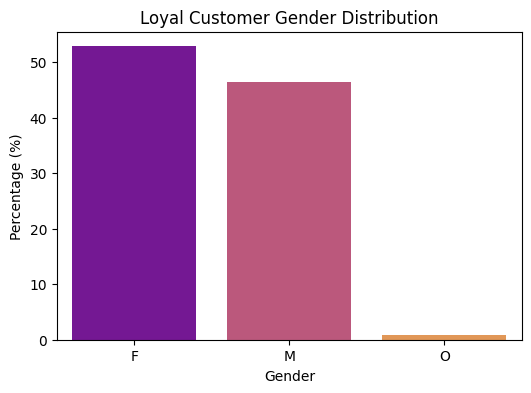

In [199]:
# person 중복 제거
unique_customer_gender = final_loyal_customer.drop_duplicates(subset=['person'])

# 성별 비율 계산
gender_counts = unique_customer_gender['gender'].value_counts()
gender_ratios = unique_customer_gender['gender'].value_counts(normalize=True) * 100

# 성별은 충성 고객과 크게 연관이 없음
plt.figure(figsize=(6, 4))
sns.barplot(x=gender_ratios.index, y=gender_ratios.values, palette='plasma')
plt.title('Loyal Customer Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Percentage (%)')
plt.show()

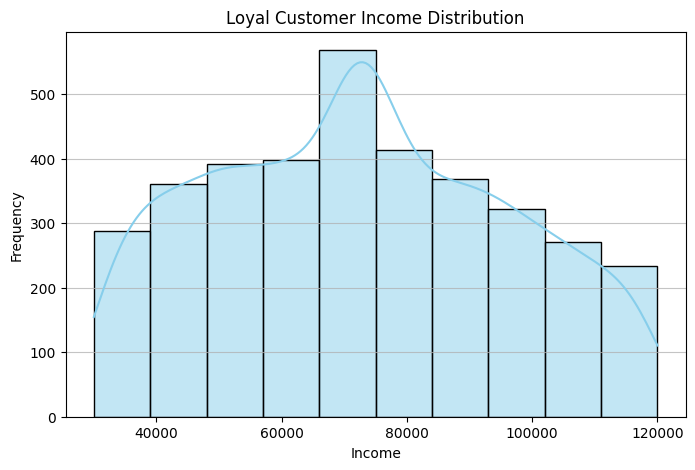

In [200]:
# 소득 분포 시각화

plt.figure(figsize=(8, 5))
sns.histplot(final_loyal_customer['income'], bins=10, kde=True, color='skyblue')
plt.title('Loyal Customer Income Distribution')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

/tmp/ipython-input-2998956259.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=generation_ratios.index, y=generation_ratios.values, palette='plasma')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48288 (\N{HANGUL SYLLABLE BE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48528 (\N

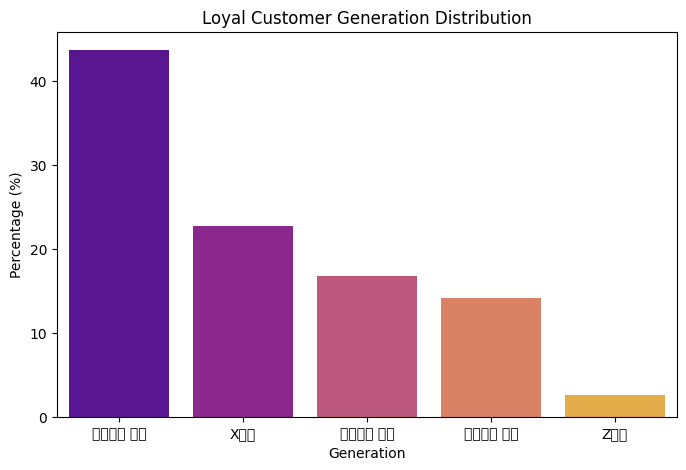

In [201]:
# person 중복 제거
unique_customer_generation = final_loyal_customer.drop_duplicates(subset=['person'])

# 세대(generation) 분포 계산
generation_counts = unique_customer_generation['generation'].value_counts()
generation_ratios = unique_customer_generation['generation'].value_counts(normalize=True) * 100

# 세대 분포 시각화 (막대 그래프)
plt.figure(figsize=(8, 5))
sns.barplot(x=generation_ratios.index, y=generation_ratios.values, palette='plasma')
plt.title('Loyal Customer Generation Distribution')
plt.xlabel('Generation')
plt.ylabel('Percentage (%)')
plt.show()

/tmp/ipython-input-1014832756.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=generation_ratios.index, y=generation_ratios.values, palette='plasma')


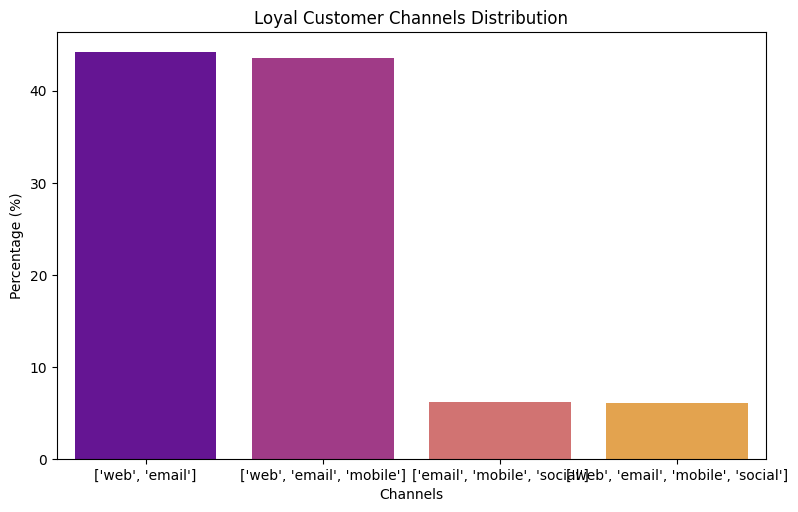

In [202]:
# person 중복 제거
unique_customer_channels = final_loyal_customer.drop_duplicates(subset=['person'])

# 세대(generation) 분포 계산
generation_counts = unique_customer_channels['channels'].value_counts()
generation_ratios = unique_customer_channels['channels'].value_counts(normalize=True) * 100

# 세대 분포 시각화 (막대 그래프)
plt.figure(figsize=(8, 5))
sns.barplot(x=generation_ratios.index, y=generation_ratios.values, palette='plasma')
plt.tight_layout()
plt.title('Loyal Customer Channels Distribution')
plt.xlabel('Channels')
plt.ylabel('Percentage (%)')
plt.show()

이탈 고객
- received -> viewed 까지만 프로모션을 진행한 고객

In [203]:
churned_customer = offer_status[(offer_status['offer viewed'] >= 1) & (offer_status['offer received'] >= 1) & (offer_status['offer completed'] == 0)]

/tmp/ipython-input-3467749378.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_ratios.index, y=gender_ratios.values, palette='plasma')


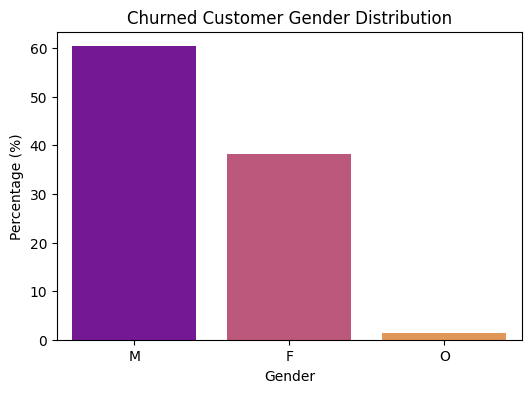

In [204]:
# person 중복 제거
unique_customer_gender = churned_customer.drop_duplicates(subset=['person'])

# 성별 비율 계산
gender_counts = unique_customer_gender['gender'].value_counts()
gender_ratios = unique_customer_gender['gender'].value_counts(normalize=True) * 100

# 성별은 충성 고객과 크게 연관이 없음
plt.figure(figsize=(6, 4))
sns.barplot(x=gender_ratios.index, y=gender_ratios.values, palette='plasma')
plt.title('Churned Customer Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Percentage (%)')
plt.show()

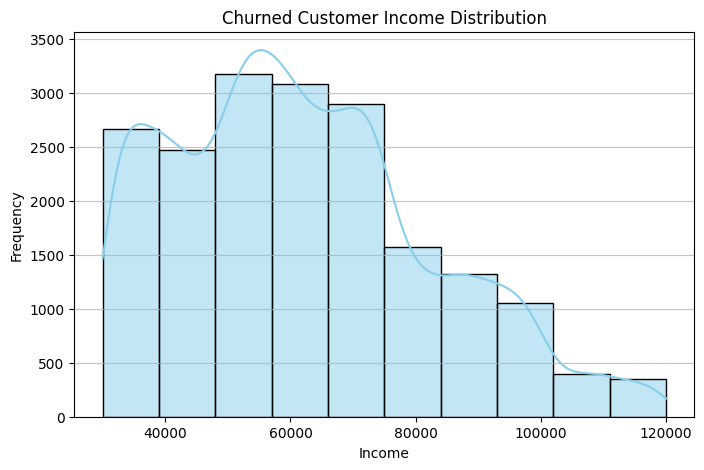

In [205]:
# 소득 분포 시각화
# 상대적으로 소득이 낮음
# 할인 위주의 프로모션을 더 늘리는 건 어떨까

plt.figure(figsize=(8, 5))
sns.histplot(churned_customer['income'], bins=10, kde=True, color='skyblue')
plt.title('Churned Customer Income Distribution')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

/tmp/ipython-input-1917912786.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=generation_ratios.index, y=generation_ratios.values, palette='plasma')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48288 (\N{HANGUL SYLLABLE BE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48528 (\N

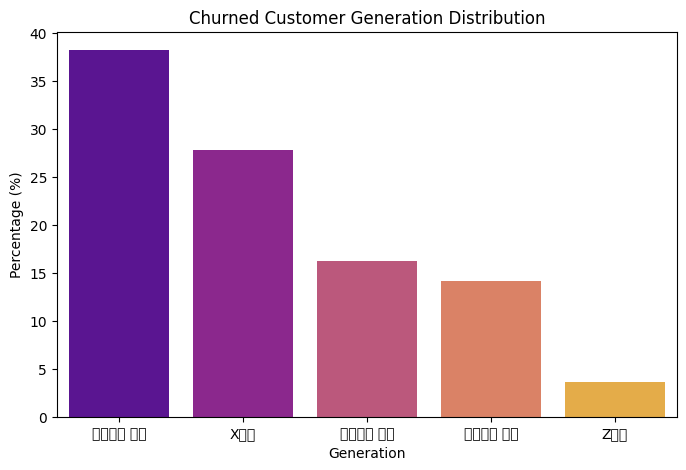

In [206]:
# 세대 차이는 크게 없음

# person 중복 제거
unique_customer_generation = churned_customer.drop_duplicates(subset=['person'])

# 세대(generation) 분포 계산
generation_counts = unique_customer_generation['generation'].value_counts()
generation_ratios = unique_customer_generation['generation'].value_counts(normalize=True) * 100

# 세대 분포 시각화 (막대 그래프)
plt.figure(figsize=(8, 5))
sns.barplot(x=generation_ratios.index, y=generation_ratios.values, palette='plasma')
plt.title('Churned Customer Generation Distribution')
plt.xlabel('Generation')
plt.ylabel('Percentage (%)')
plt.show()

/tmp/ipython-input-2754303905.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=generation_ratios.index, y=generation_ratios.values, palette='plasma')


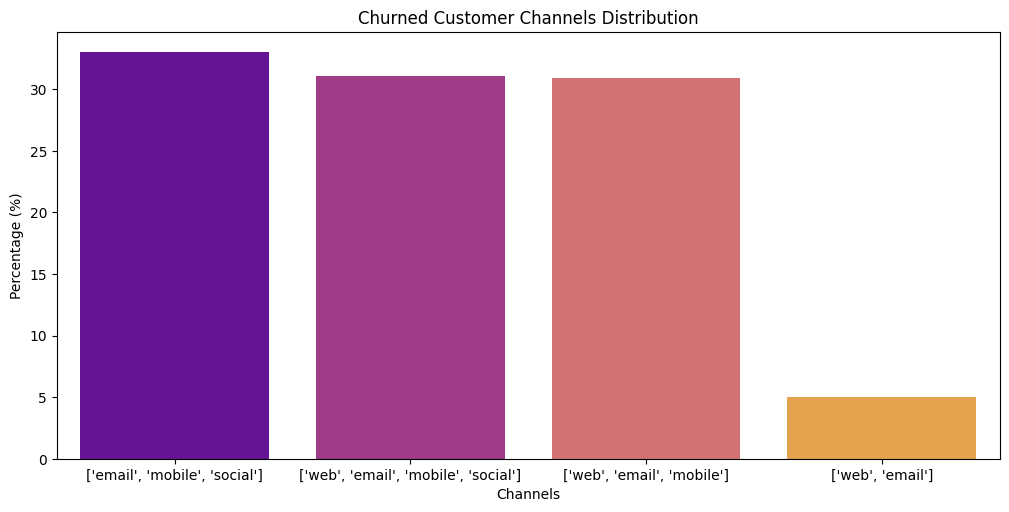

In [207]:
# person 중복 제거
unique_customer_channels = churned_customer.drop_duplicates(subset=['person'])

# 세대(generation) 분포 계산
generation_counts = unique_customer_channels['channels'].value_counts()
generation_ratios = unique_customer_channels['channels'].value_counts(normalize=True) * 100

# 세대 분포 시각화 (막대 그래프)
plt.figure(figsize=(10, 5))
sns.barplot(x=generation_ratios.index, y=generation_ratios.values, palette='plasma')
plt.tight_layout()
plt.title('Churned Customer Channels Distribution')
plt.xlabel('Channels')
plt.ylabel('Percentage (%)')
plt.show()

분석 결과
- 성별, 소득이 충성 고객과 이탈 고객을 결정 짓는 요소
- 통계 분석 필요

### 6-4-2) 충성 고객과 이탈 고객 통계 분석

성별 차이 카이제곱 검정

- Ho: 충성 고객과 중간 이탈 고객 사이에 성별 분포가 차이가 없다.
- H1: 충성 고객과 중간 이탈 고객 사이에 성별 분포가 치이가 있다.

In [208]:
# 성별 분포를 나타내는 테이블 생성
gender_loyal = final_loyal_customer['gender'].value_counts()
gender_churned = churned_customer['gender'].value_counts()

In [209]:
# 교차표 생성
contingency_table = pd.DataFrame({
    'Loyal Customer': gender_loyal,
    'Churned Customer': gender_churned
})

# 카이제곱 검정 실행
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-squared 검정통계량: {chi2:.2f}")
print(f"P-value: {p:.4f}")

# 결과 해석
alpha = 0.01
if p < alpha:
    print("통계적으로 유의하여 귀무가설을 기각합니다.")
else:
    print("통계적으로 유의하지 않아 귀무가설을 채택합니다.")

Chi-squared 검정통계량: 428.66
P-value: 0.0000
통계적으로 유의하여 귀무가설을 기각합니다.


채널 차이 카이제곱 검정

- Ho: 충성 고객과 중간 이탈 고객 사이에 채널 분포가 차이가 없다.
- H1: 충성 고객과 중간 이탈 고객 사이에 채널 분포가 치이가 있다.

In [210]:
# 충성 고객과 이탈 고객 채널 분포 확인을 위한 데이터셋 생성
channel_loyal = final_loyal_customer['channels'].value_counts()
channel_churned = churned_customer['channels'].value_counts()

In [211]:
# 교차표 생성
contingency_table = pd.DataFrame({
    'Loyal Customer': channel_loyal,
    'Churned Customer': channel_churned
})

# 카이제곱 검정 실행
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-squared 검정통계량: {chi2:.2f}")
print(f"P-value: {p:.4f}")

# 결과 해석
alpha = 0.01
if p < alpha:
    print("통계적으로 유의하여 귀무가설을 기각합니다.")
else:
    print("통계적으로 유의하지 않아 귀무가설을 채택합니다.")

Chi-squared 검정통계량: 6394.64
P-value: 0.0000
통계적으로 유의하여 귀무가설을 기각합니다.


소득 차이 카이제곱 검정

- Ho: 두 그룹의 소득 분포 차이가 없다.(또는 중앙값이 동일하다.)
- H1: 두 그룹의 소득 분포 차이가 있다.(또는 중앙값이 다르다.)

In [212]:
# 정규성 검정
loyal_income = final_loyal_customer['income']
churned_income = churned_customer['income']

# 샤피로 검정으로 정규성 확인
shapiro_loyal = shapiro(loyal_income)
shapiro_churned = shapiro(churned_income)

if (shapiro_loyal.pvalue < 0.01) or (shapiro_churned.pvalue < 0.01):
  print("두 그룹 모두 정규분포를 따르니 t 검정")
else:
  print("한 그룹 이상 정규분포를 따르지 않을 수 있으니 비모수 검정인 맨-위트니 U 검정 사용")

# 샘플이 너무 많아 중심극한정리에 따라 정규분포로 수렴할 수 있음.
# 하지만 이탈 고객의 소득 그래프는 정규 분포를 띄고 있지 않음. 안전하게 비모수 검정인 맨-위트니 U 검정 사용.

두 그룹 모두 정규분포를 따르니 t 검정


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 18994.
  res = hypotest_fun_out(*samples, **kwds)


In [213]:
mannwhitney_income = mannwhitneyu(loyal_income, churned_income, alternative='two-sided')

if mannwhitney_income.pvalue < 0.01:
  print("두 그룹 간 소득 분포 차이가 있어 귀무가설을 기각합니다.")
else:
  print("두 그룹 간 소득 분포 차이가 없어 귀무가설을 채택합니다.")

두 그룹 간 소득 분포 차이가 있어 귀무가설을 기각합니다.


# 6-5 배승인

## 6-5-1) 성별별 프로모션 유형별 비율

In [311]:
# 인포메이션 한번 제외
starbucks_nan = starbucks[starbucks['offer_type'] != 'informational'].copy()

filter = starbucks[
    (starbucks['gender'].isin(['M', 'F'])) &
    (starbucks_nan['offer_type'] != 'informational')
]

# 성별 × 프로모션유형별 이벤트 비율 계산
segmented = (
    filter.groupby(['gender','offer_type'])['event']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)


segmented['completion_rate'] = (
    segmented['offer completed'] / segmented['offer received'] * 100
).round(1)
segmented

event              offer received  offer viewed  offer completed  \
gender offer_type                                                  
F      bogo              0.398338      0.331845         0.269817   
       discount          0.412042      0.291174         0.296784   
M      bogo              0.431874      0.357273         0.210854   
       discount          0.443514      0.301309         0.255178   

event              completion_rate  
gender offer_type                   
F      bogo                   67.7  
       discount               72.0  
M      bogo                   48.8  
       discount               57.5

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50756 (\N{HANGUL SYLLABLE WAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47308 (\N{HANGUL SYLLABLE RYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

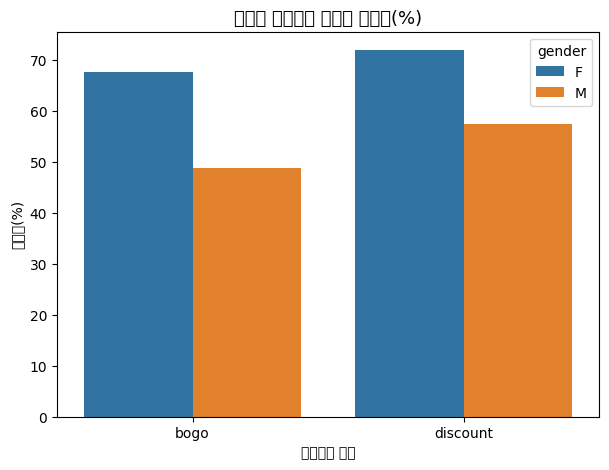

In [312]:
segmented_reset = segmented.reset_index()

plt.figure(figsize=(7,5))
sns.barplot(
    data=segmented_reset,
    x='offer_type',
    y='completion_rate',
    hue='gender'
)
plt.title('성별별 프로모션 유형별 완료율(%)', fontsize=13)
plt.ylabel('완료율(%)')
plt.xlabel('프로모션 유형')
plt.show()

In [313]:
portfolio[['offer_type','difficulty','reward','duration']].drop_duplicates()

,offer_type,difficulty,reward,duration
0,bogo,10,10,7
1,bogo,10,10,5
2,informational,0,0,4
3,bogo,5,5,7
4,discount,20,5,10
5,discount,7,3,7
6,discount,10,2,10
7,informational,0,0,3
8,bogo,5,5,5
9,discount,10,2,7


In [314]:
# offer 구간 별 피벗 테이블 생성
timeline = (
    starbucks_nan[starbucks_nan['event'].isin(['offer received','offer viewed','offer completed'])]
    .pivot_table(
        index=['person','offer_id','offer_type','difficulty','reward_p','duration'],
        columns='event',
        values='time',
        aggfunc='min'
    )
    .reset_index()
)
timeline.to_csv('timeline_dropoff.csv', index=False,encoding='utf-8-sig')
timeline.columns

Index(['person', 'offer_id', 'offer_type', 'difficulty', 'reward_p',
       'duration', 'offer completed', 'offer received', 'offer viewed'],
      dtype='object', name='event')

## 6-5-2 구간 별 반응 속도 계산

In [317]:
#시간 흐름(받고->보고->완료) 순의 경우만 남긴 행/시간 정제

valid = timeline[
    (timeline['offer viewed'] > timeline['offer received']) &
    (timeline['offer completed'] > timeline['offer viewed'])
].copy()

#같은 고객이 받은 중복 이벤트 제외
timeline_clean = (
    valid.sort_values(['person','offer_id','offer received'])
    .drop_duplicates(['person','offer_id'], keep='first')
    .reset_index(drop=True)
)
#응답지연 (받고~본 시점, 보고 완료 시점)
timeline_clean['view_delay'] = timeline_clean['offer viewed'] - timeline_clean['offer received']
timeline_clean['complete_delay'] = timeline_clean['offer completed'] - timeline_clean['offer viewed']

In [318]:
timeline_dropoff = timeline[
    (timeline['offer viewed'].isna() | (timeline['offer viewed'] > timeline['offer received'])) &
    (timeline['offer completed'].isna() | (timeline['offer completed'] > timeline['offer viewed']))
].copy()

In [319]:
# 이탈 구간 확인

def dropoff_stage(row):
    if pd.isna(row['offer viewed']):
        return '확인안함'      # 프로모션을 받고 확인은 안함
    elif pd.isna(row['offer completed']):
        return '완료안함'    # 프로모션은 받고 완료를안함
    else:
        return '완료'

timeline_dropoff['이탈단계'] = timeline_dropoff.apply(dropoff_stage, axis=1)

print(timeline_dropoff['이탈단계'].value_counts())

이탈단계
완료      13506
완료안함    12076
확인안함     6275
Name: count, dtype: int64


In [320]:
# 구간 별 person 비율

summary = (
    timeline_dropoff
    .groupby(['offer_type','difficulty','reward_p','duration','이탈단계'])
    .size()                      # 각 그룹의 개수
    .unstack(fill_value=0)       # '이탈단계'를 가로로 펼치기 (완료, 완료안함, 확인안함)
    .reset_index()
)

# 조건별 총 참여자 수
summary['전체'] = summary[['완료','완료안함','확인안함']].sum(axis=1)

# 각 조건 안에서 몇 %가 이탈했는지
summary['완료안한비율'] = (summary['완료안함'] / summary['전체'] * 100).round(2)
summary['확인안한비율'] = (summary['확인안함'] / summary['전체'] * 100).round(2)
summary['완료비율']     = (summary['완료'] / summary['전체'] * 100).round(2)

# 4️전체대비 비중 (전체 timeline 기준으로 몇 %인가)
total_n = len(timeline)
summary['전체대비_완료안한비중'] = (summary['완료안함'] / total_n * 100).round(2)
summary['전체대비_확인안한비중'] = (summary['확인안함'] / total_n * 100).round(2)
summary['전체대비_완료비중']     = (summary['완료'] / total_n * 100).round(2)

summary = summary.sort_values('전체대비_완료안한비중', ascending=False)

summary.to_csv('summary.csv',index=False, encoding='utf-8-sig')
summary

이탈단계,offer_type,difficulty,reward_p,duration,완료,완료안함,확인안함,전체,완료안한비율,확인안한비율,완료비율,전체대비_완료안한비중,전체대비_확인안한비중,전체대비_완료비중
2,bogo,10.0,10.0,5.0,1428,2501,138,4067,61.49,3.39,35.11,4.94,0.27,2.82
3,bogo,10.0,10.0,7.0,1536,2292,344,4172,54.94,8.25,36.82,4.53,0.68,3.03
0,bogo,5.0,5.0,5.0,1838,1827,116,3781,48.32,3.07,48.61,3.61,0.23,3.63
4,discount,7.0,3.0,7.0,2395,1374,95,3864,35.56,2.46,61.98,2.71,0.19,4.73
6,discount,10.0,2.0,10.0,2613,1273,85,3971,32.06,2.14,65.80,2.51,0.17,5.16
5,discount,10.0,2.0,7.0,1369,1002,1612,3983,25.16,40.47,34.37,1.98,3.18,2.70
1,bogo,5.0,5.0,7.0,1339,968,1417,3724,25.99,38.05,35.96,1.91,2.80,2.64
7,discount,20.0,5.0,10.0,988,839,2468,4295,19.53,57.46,23.00,1.66,4.87,1.95


## 6-5-3) 프로모션 조건 별 비율

/tmp/ipython-input-3969370513.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53448 (\N{HANGUL SYLLABLE TAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools

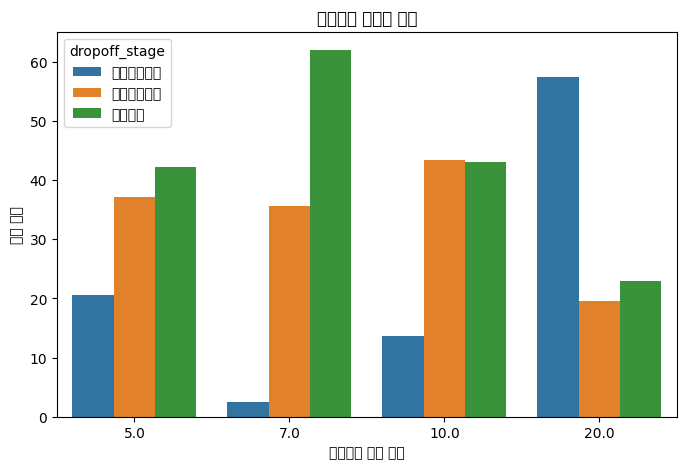

In [321]:
# 난이도가 높을수록 이탈률이 커지는지
plt.figure(figsize=(8,5))
sns.barplot(
    data=summary.melt(
        id_vars=['offer_type','difficulty','reward_p','duration'],
        value_vars=['확인안한비율','완료안한비율','완료비율'],
        var_name='dropoff_stage', value_name='ratio'
    ),
    x='difficulty', y='ratio', hue='dropoff_stage',ci=None
)
plt.title('프로모션 조건별 비율')
plt.xlabel('프로모션 지출 비용')
plt.ylabel('이탈 비율')
plt.show()

## 6-5-3) 프로모션 유형별로 지출금액 대비 이탈률보기

/tmp/ipython-input-2576449359.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipython-input-2576449359.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipython-input-2576449359.py:23: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2576449359.py:23: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2576449359.py:23: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2576449359.py:23: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2576449359.py:23: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

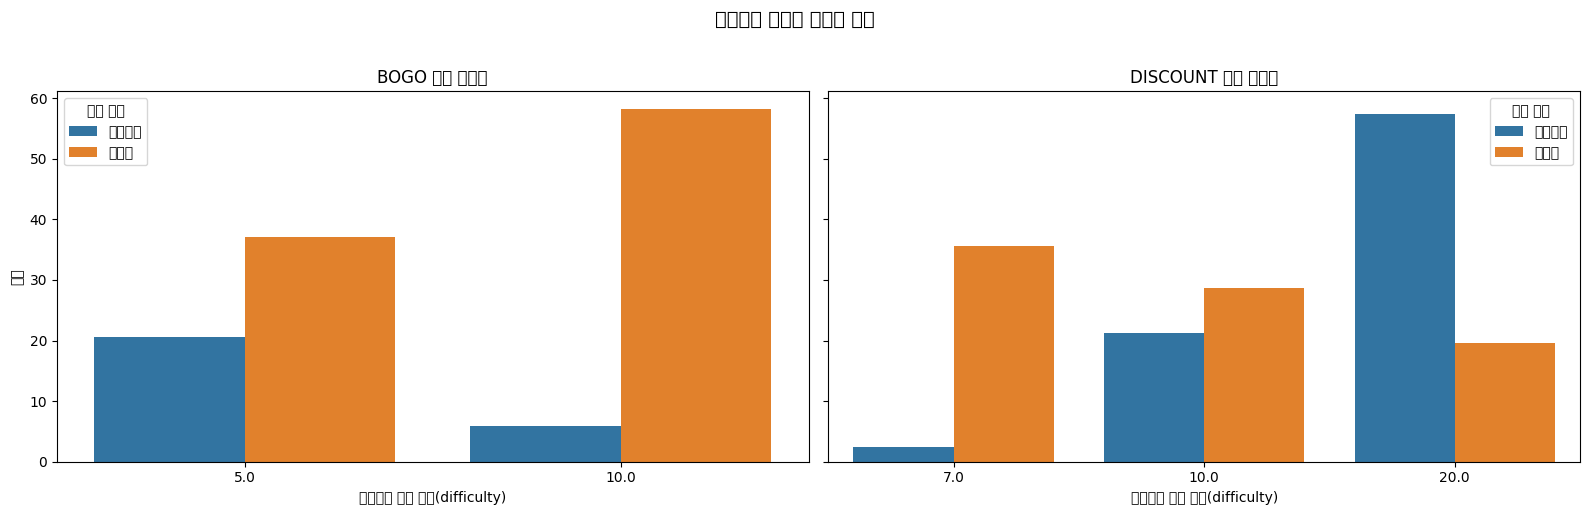

In [323]:
# offer type 정의
offer_types = summary['offer_type'].unique()

# 그래프를 한번에 보여주기
fig, axes = plt.subplots(1, len(offer_types), figsize=(16,5), sharey=True)

for i, ot in enumerate(offer_types):
    ax = axes[i]
    sns.barplot(
        data=summary[summary['offer_type']==ot].melt(
            id_vars=['difficulty','reward_p','duration'],
            value_vars=['확인안한비율','완료안한비율'],
            var_name='dropoff_stage', value_name='ratio'
        ),
        x='difficulty', y='ratio', hue='dropoff_stage', ax=ax,ci=None
    )
    ax.set_title(f'{ot.upper()} 유형 이탈률')
    ax.set_xlabel('프로모션 지출 금액(difficulty)')
    ax.set_ylabel('비율')
    ax.legend(title='이탈 단계', labels=['보지않음', '미완료'])

plt.suptitle('프로모션 유형별 이탈률 비교', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [324]:
# summary 데이터 기준으로 이탈률 계산
drop_summary = (
    summary.groupby('difficulty')[['확인안한비율','완료안한비율']]
    .mean()
    .sum(axis=1)
    .reset_index(name='이탈률')
)

## 6-5-4) 이탈율: 프로모션을 받은 고객 중 끝까지 참여하지 않은 사람들의 전체 비율

/tmp/ipython-input-12356787.py:16: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-12356787.py:16: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-12356787.py:16: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-12356787.py:16: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-12356787.py:16: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-12356787.py:16: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-12356787.py:16: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-

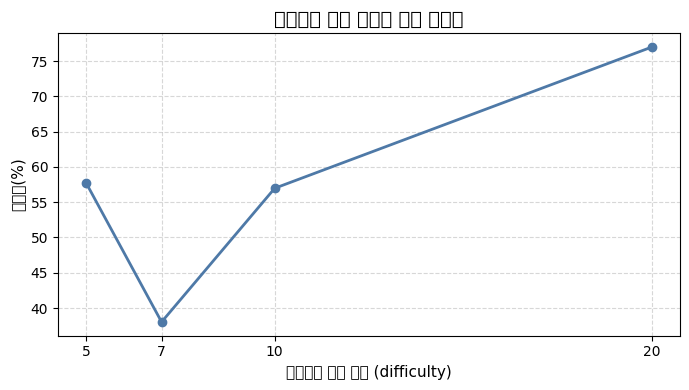

In [325]:
plt.figure(figsize=(7,4))
plt.plot(
    drop_summary['difficulty'],
    drop_summary['이탈률'],
    marker='o',
    color='#4E79A7',
    linewidth=2
)

plt.title('프로모션 지출 금액별 평균 이탈률', fontsize=14)
plt.xlabel('프로모션 지출 금액 (difficulty)', fontsize=11)
plt.ylabel('이탈률(%)', fontsize=11)
plt.xticks(drop_summary['difficulty'])
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 6-5-5) 프로모션 유형별 고객 완료율

In [326]:
# 단계별로 고객수 계산해서
stage_count = (
    starbucks_nan[starbucks_nan['event'].isin(['offer received','offer viewed','offer completed'])]
    .groupby(['offer_type','event'])['person']
    .nunique()
    .unstack(fill_value=0)
    .reset_index()
)

# 전체 대비 비율계산하고
stage_count['view_rate'] = (stage_count['offer viewed'] / stage_count['offer received']).round(3)
stage_count['complete_rate'] = (stage_count['offer completed'] / stage_count['offer received']).round(3)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44061 (\N{HANGUL SYLLABLE GAEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lo

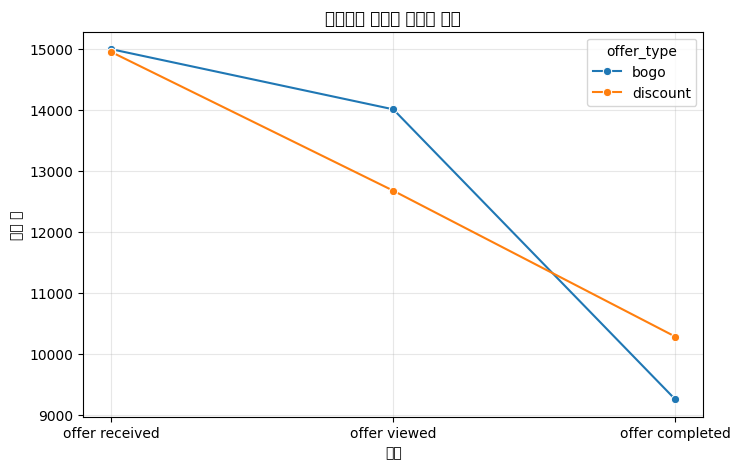

In [327]:
# 단계별로 이어지게 보이기위해서 melt 씀
stage_line = stage_count.melt(id_vars='offer_type',
                              value_vars=['offer received','offer viewed','offer completed'],
                              var_name='단계', value_name='고객수')

plt.figure(figsize=(8,5))
sns.lineplot(data=stage_line, x='단계', y='고객수', hue='offer_type', marker='o')
plt.title('프로모션 유형별 고객수 추이')
plt.xlabel('단계')
plt.ylabel('고객 수')
plt.grid(alpha=0.3)
plt.show()

## 6-5-6) 프로모션 조건별로 완료율

In [328]:
funnel = (
     timeline.groupby(['offer_type','difficulty','reward_p','duration'])
    .apply(lambda df: pd.Series({
        '확인 비율': round(df['offer viewed'].notna().mean(), 2),
        '완료 비율': round(df['offer completed'].notna().mean(), 2)
    }))
).reset_index()
funnel.to_csv('promotion_funnel.csv', index=False,encoding='utf-8-sig')

funnel

/tmp/ipython-input-2662388592.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({


,offer_type,difficulty,reward_p,duration,확인 비율,완료 비율
0,bogo,5.0,5.0,5.0,0.97,0.60
1,bogo,5.0,5.0,7.0,0.58,0.60
2,bogo,10.0,10.0,5.0,0.97,0.46
3,bogo,10.0,10.0,7.0,0.89,0.50
4,discount,7.0,3.0,7.0,0.97,0.70
5,discount,10.0,2.0,7.0,0.57,0.55
6,discount,10.0,2.0,10.0,0.97,0.72
7,discount,20.0,5.0,10.0,0.38,0.47


## 6-5-6) 프로모션 유효 기간 별 비율

/tmp/ipython-input-1259221263.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtool

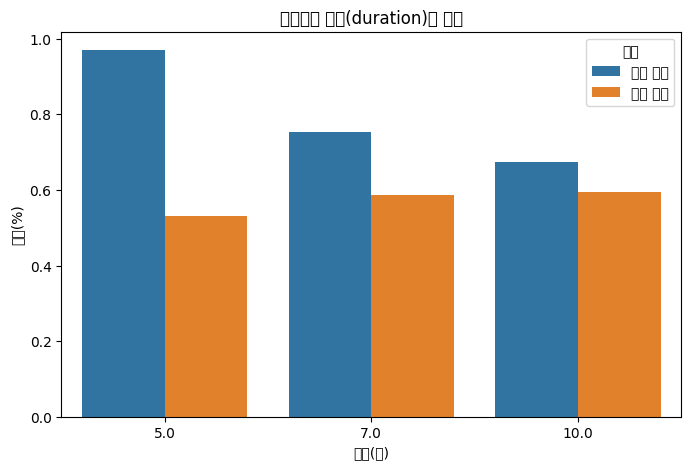

In [329]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=funnel.melt(
        id_vars=['offer_type','difficulty','reward_p','duration'],
        value_vars=['확인 비율','완료 비율'],
        var_name='단계', value_name='비율'
    ),
    x='duration', y='비율', hue='단계', ci=None
)
plt.title('프로모션 기간(duration)별 비율')
plt.xlabel('기간(일)')
plt.ylabel('비율(%)')
plt.show()

In [330]:
# 완료까지 걸린 일수 계산
timeline_clean['완료까지_일수'] = (timeline_clean['offer completed'] - timeline_clean['offer received'])/24

# 구간(bins) 정의: 1일 이내 / 1~3일 / 3~7일 / 7일 이상
bins = [-np.inf, 1, 3, 7, np.inf]
labels = ['1일이내', '1~3일', '3~7일', '7일이상']

# 완료까지 걸린 시간을 기준으로 구간 분류
timeline_clean['반응속도'] = pd.cut(timeline_clean['완료까지_일수'], bins=bins, labels=labels)

In [332]:
# 시간 정제한 타임라인 클린 변수로, 반응속도
speed_ct = pd.crosstab(timeline_clean['duration'], timeline_clean['반응속도'])
print(" 유효기간별 반응속도군 분포 (건수)")
print(speed_ct)

 유효기간별 반응속도군 분포 (건수)
반응속도      1일이내  1~3일  3~7일  7일이상
duration                        
5.0        504  1590   926   246
7.0        757  2673  2773   436
10.0       293  1178  1479   651


## 6-5-7) 통계 검정

In [333]:
# 듀레이션(유효기간)이 완료율과 독립 여부 검증
chi2, p, _, _ = chi2_contingency(speed_ct)
print(f"\n카이제곱 통계량 = {chi2:.3f}, p값 = {p:.5f}")

#  각 기간별 내부 비율(%) 계산 — 표본 크기 보정
speed_pct = speed_ct.div(speed_ct.sum(axis=1), axis=0) * 100
speed_pct = speed_pct.round(2)
print("\n 유효기간별 반응속도군 비율(%)")


카이제곱 통계량 = 637.390, p값 = 0.00000

 유효기간별 반응속도군 비율(%)


/tmp/ipython-input-1514101069.py:13: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1514101069.py:13: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1514101069.py:13: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1514101069.py:13: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1514101069.py:13: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1514101069.py:13: UserWarning: Glyph 54952 (\N{HANGUL SYLLABLE HYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1514101069.py:13: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/

<Figure size 900x600 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54952 (\N{HANGUL SYLLABLE HYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lo

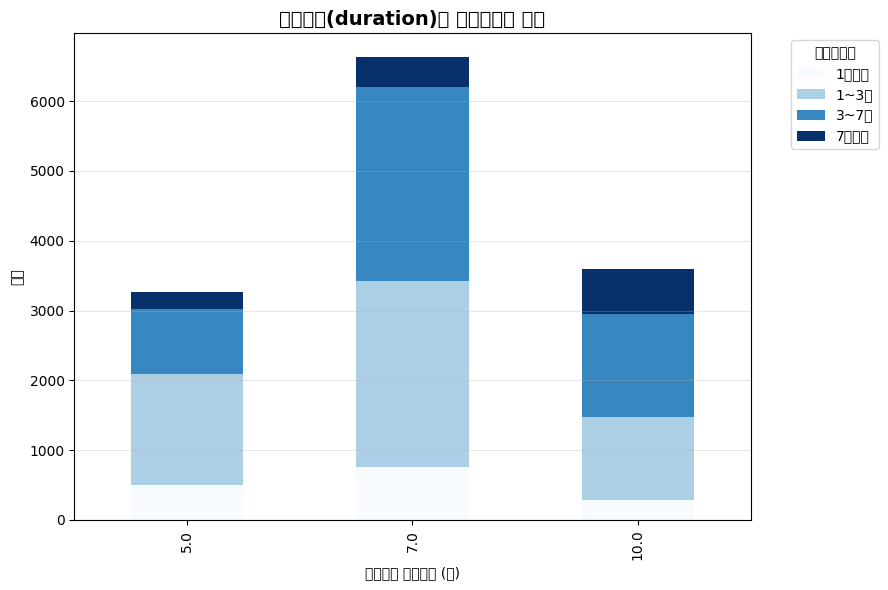

In [334]:
plt.figure(figsize=(9,6))
speed_ct.plot(
    kind='bar',
    stacked=True,
    colormap='Blues',
    figsize=(9,6)
)
plt.title('유효기간(duration)별 반응속도군 건수', fontsize=14, fontweight='bold')
plt.xlabel('프로모션 유효기간 (일)')
plt.ylabel('건수')
plt.legend(title='반응속도군', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 3~7일 구간의 비율이 가장 크고, 특히 duration이 7일일 때 그 비중이 더 커진다

In [335]:
# 프로모션 지출금액과 완료율간 상관관계
from scipy.stats import spearmanr

# 난이도별 완료율 계산
difficulty_complete = (
    timeline.groupby('difficulty')['offer completed']
    .apply(lambda x: x.notna().mean())
    .reset_index(name='완료율')
)

corr, p = spearmanr(difficulty_complete['difficulty'], difficulty_complete['완료율'])
print(difficulty_complete)
print(f"Spearman 상관계수 = {corr:.3f}, p값 = {p:.4f}")

#음의 상관관계로 강한 상관관계는 보이나, 우연히 일어날 확률이 큼

   difficulty       완료율
0         5.0  0.596418
1         7.0  0.698972
2        10.0  0.555744
3        20.0  0.467211
Spearman 상관계수 = -0.800, p값 = 0.2000


In [336]:
# 프로모션 유형별 완료까지 걸린 시간
from scipy.stats import kruskal

done = timeline_clean.dropna(subset=['완료까지_일수']).copy()
# print(done.groupby('offer_type')['완료까지_일수'].describe().round(2))

groups = [g['완료까지_일수'] for _, g in done.groupby('offer_type')]
stat, p = kruskal(*groups)

print(f"\nKruskal-Wallis 통계량 = {stat:.3f}, p값 = {p:.5f}")


Kruskal-Wallis 통계량 = 268.465, p값 = 0.00000


In [337]:
# 프로모션 조건(난이도 × 유효기간)과 완료여부의 연관성
from scipy.stats import chi2_contingency

timeline['완료여부'] = timeline['offer completed'].notna().astype(int)
ct = pd.crosstab(
    [timeline['difficulty'], timeline['duration']],
    timeline['완료여부']
)
chi2, p, _, _ = chi2_contingency(ct)
print(ct)
print(f"카이제곱 통계량 = {chi2:.3f}, p값 = {p:.5f}")

# 절대적 차이는 크진않은데, 비율의차이를봤을때 차이가있음

완료여부                    0     1
difficulty duration            
5.0        5.0       2521  3741
           7.0       2571  3784
7.0        7.0       1904  4421
10.0       5.0       3445  2885
           7.0       6002  6657
           10.0      1802  4530
20.0       10.0      3396  2978
카이제곱 통계량 = 1725.070, p값 = 0.00000


---
# 7️⃣ 페이지 분석

## 7-1) KPI

### 7-1-1) Active User (Offer Recieved)

In [214]:
# 주차별로 offer recieved를 받은 고객
week_received = starbucks_cp.loc[starbucks_cp['event'] == 'offer received']
week_received = week_received.groupby('week')['person'].nunique()
week_received

,person
week,
1,12650
2,12669
3,15930
4,15919


### 7-1-2) Active User (Offer Completed)

In [215]:
# 주차별로 Offer Completed를 완수한 고객
week_completed = starbucks_cp.loc[starbucks_cp['event'] == 'offer completed']
week_completed = week_completed.groupby('week')['person'].nunique()
week_completed

,person
week,
1,4380
2,5178
3,7242
4,8096
5,1850


### 7-1-3) Conversion (참여율)

In [216]:
# 시리즈 병합: week_received + week_completed
conversion = pd.concat([week_received, week_completed], axis=1).reset_index()

# 컬럼명 수정
conversion.columns = ["week", "received", "completed"]

# 참여율 계산: completed / received
conversion["rate"] = round((conversion["completed"] /
                            conversion["received"]) * 100, 2)
conversion

,week,received,completed,rate
0,1,12650.0,4380,34.62
1,2,12669.0,5178,40.87
2,3,15930.0,7242,45.46
3,4,15919.0,8096,50.86
4,5,NaN,1850,NaN


### 7-1-4) Sales (Amount)

In [217]:
# 매출이 있는 행만 필터
amount = starbucks_cp.loc[starbucks_cp['event'] == 'transaction']

# 주차별 매출 합계 계산
amount = amount.groupby('week')['amount'].sum()
amount

,amount
week,
1,287823.85
2,368592.39
3,441276.52
4,501543.40
5,176215.81


### 7-1-5) Sales (주문 고객 수)

In [218]:
week_transaction = starbucks_cp.loc[starbucks_cp['event'] == 'transaction']
week_transaction = week_transaction.groupby('week')['person'].nunique()
week_transaction

,person
week,
1,10574
2,12708
3,13937
4,14425
5,8969


### 7-1-6) Sales (ARPU)

In [219]:
# 계산: 주차별 매출 / 주차별 유니크 고객 수
arpu = starbucks_cp.groupby('week').agg({"person":"nunique", "amount":"sum"})
arpu['amount_per_person'] = round(arpu['amount'] /
                                  arpu['person'], 2)
arpu

,person,amount,amount_per_person
week,,,
1,14767,287823.85,19.49
2,15566,368592.39,23.68
3,16716,441276.52,26.40
4,16790,501543.40,29.87
5,9520,176215.81,18.51


### 7-1-7) Sales (재구매율)

In [220]:
# 주차별 2회 이상 구매 고객 수
two_more_pur = transcript_merged.loc[~(transcript_merged['weight_amount'] == 0.00)]
two_more_pur = two_more_pur.groupby(['week', 'person'])['weight_amount'].size()
two_more_pur = two_more_pur[two_more_pur >= 2].reset_index()[['week', 'person']]
two_more_pur = two_more_pur.groupby('week')['person'].nunique()
two_more_pur

# 주차별 전체 구매 고객 수
week_transaction

# 시리즈 병합: repurchase + week_transaction
repurchase = pd.concat([two_more_pur, week_transaction], axis=1).reset_index()
repurchase.columns = ["week", "two_more_pur", "total_pur"]
repurchase["rate"] = round((repurchase["two_more_pur"] /
                            repurchase["total_pur"]) * 100, 2)
repurchase

,week,two_more_pur,total_pur,rate
0,1,5835,10574,55.18
1,2,7695,12708,60.55
2,3,9393,13937,67.40
3,4,10343,14425,71.70
4,5,3194,8969,35.61


### 7-1-8) CLV (고객 생애 가치)

CLV = (평균 거래 금액 × 평균 구매 빈도) × 고객 수

In [221]:
# 주차별 평균 거래 금액
arpu['amount_per_person']

# 주차별 평균 구매 빈도
pur_frequency = starbucks_cp.loc[starbucks_cp['event'] == 'transaction', ['person', 'week', 'amount']]
pur_frequency = pur_frequency.groupby(['week', 'person']).nunique()
pur_frequency = pur_frequency.groupby('week')['amount'].mean().round(2)
pur_frequency

# 고객 수


,amount
week,
1,2.14
2,2.29
3,2.50
4,2.67
5,1.50


### 7-1-9) Conversion (Retention)

- Tableau로 구현 예정

### 7-1-10) Conversion (Funnel)

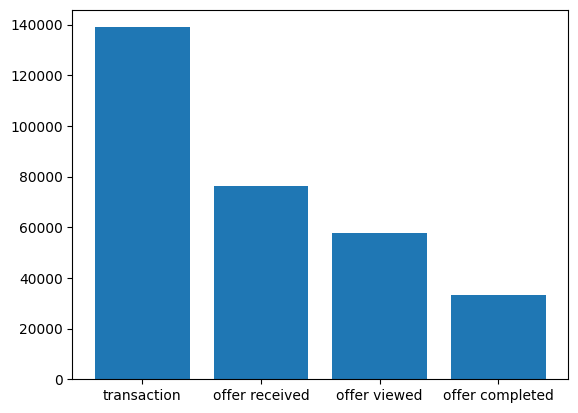

In [222]:
# 전체 참여율 흐름 (주차별 x → Tableau 필터로 나눌 예정)
funnel = starbucks_cp.groupby('event')['person'].size().sort_values(ascending=False)

plt.bar(funnel.index, funnel.values)
plt.show()

In [223]:
transcript_merged['event'].value_counts()

,count
event,
transaction,141518
offer received,76277
offer viewed,57725
offer completed,33182


## 7-2) 프로모션 정보

### 7-2-1) 프로모션 유형

In [224]:
portfolio.groupby('offer_type').size().sort_values(ascending=False)

,0
offer_type,
bogo,4
discount,4
informational,2


### 7-2-2) 홍보 수단

In [225]:
portfolio.groupby('channels').size().sort_values(ascending=False)

,0
channels,
"['web', 'email', 'mobile', 'social']",4
"['web', 'email', 'mobile']",3
"['email', 'mobile', 'social']",2
"['web', 'email']",1


### 7-2-3) 유형별 평균 실시 기간 / 리워드 / 고객 지출

In [226]:
portfolio.groupby('offer_type').agg({"duration":"mean",
                                     "reward":"mean",
                                     "difficulty":"mean"})

,duration,reward,difficulty
offer_type,,,
bogo,6.0,7.5,7.50
discount,8.5,3.0,11.75
informational,3.5,0.0,0.00


## 7-3) 고객 정보

In [227]:
# profile을 계산하기 위해
# 결측값 대체 → NONE
profile['gender'] = profile['gender'].fillna('NONE')
profile['income'] = profile['income'].fillna('NONE')
print(f"성별 결측값: {profile['gender'].isna().sum()}")
print(f"소득 결측값: {profile['income'].isna().sum()}")

# 이상값 대체 → NONE
profile.loc[profile['age'] == 118.0, 'age'] = np.nan

성별 결측값: 0
소득 결측값: 0


### 7-3-1) 고객 성별 분포

In [228]:
profile['gender'].value_counts()

,count
gender,
M,8484
F,6129
NONE,2175
O,212


### 7-3-2) 고객 나이 분포

<Axes: >

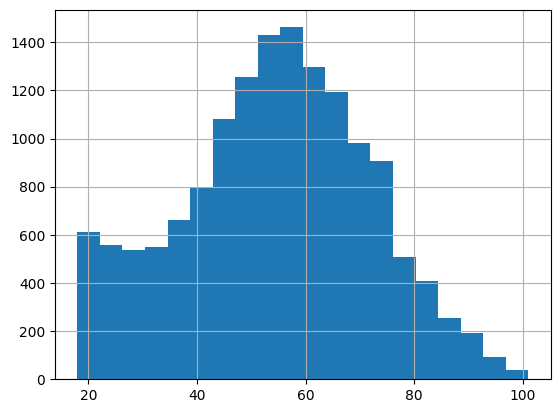

In [229]:
profile['age'].hist(bins=20)

### 7-3-3) 고객 멤버십 가입일 분포

<Axes: >

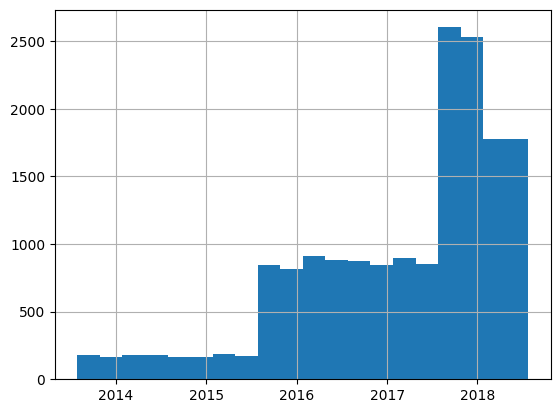

In [230]:
profile['became_member_on'].hist(bins=20)

### 7-3-4) 고객 연간 소득액 분포

<Axes: >

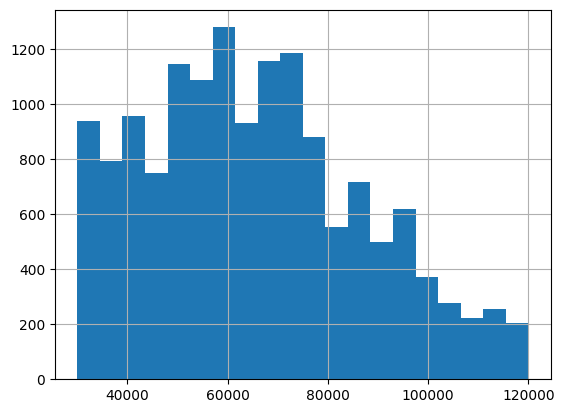

In [231]:
profile['income'] = pd.to_numeric(profile['income'], errors='coerce')
profile['income'].hist(bins=20)

# 🤖머신러닝 모델링

In [232]:
# xgboost와 lgbm을 설치합니다.
!pip install XGBoost
!pip install LGBM

ERROR: Could not find a version that satisfies the requirement LGBM (from versions: none)
ERROR: No matching distribution found for LGBM


In [233]:
# 필요한 sklearn api와 xgboost 모델을 호출합니다.

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, roc_curve

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

## 학습 데이터셋 생성
- 신규 고객이 들어오면 추천 프로모션을 분류하는 이진 분류 모델
- 정량화 할 수 있는 고객 변수, 고객 생존 시간, 고객 프로모션 참여 여부를 학습 데이터로 사용

In [234]:
# customer_offer_journey_normal에서 필요한 컬럼만 추출
# category형 변수는 최대한 줄이기 위해 reaction type은 제외
customer_offer_journey_modeling = customer_offer_journey_normal[['person','offer_type', 'gender', 'age', 'became_member_on', 'log_income', 'generation', 'channels', 'time_to_view', 'time_to_complete' ,'view_to_complete']]
final_loyal_customer_modeling = final_loyal_customer[['person', 'offer completed', 'offer received', 'offer viewed']]

# 충성, 이탈 고객 정보가 담긴 final_loyal_customer와 공통된 person만 merge
modeling_dataset = pd.merge(customer_offer_journey_modeling, final_loyal_customer_modeling, how='inner', on='person')
modeling_dataset.drop(["person"], axis=1 ,inplace=True)

In [235]:
modeling_dataset.head(3)

event,offer_type,gender,age,became_member_on,log_income,generation,channels,time_to_view,time_to_complete,view_to_complete,offer completed,offer received,offer viewed
0,discount,F,26.0,2017-06-21,11.198215,밀레니얼 세대,"['web', 'email', 'mobile', 'social']",132.0,216.0,84.0,1,1,0
1,bogo,M,54.0,2016-03-31,11.502875,베이비붐 세대,"['web', 'email', 'mobile', 'social']",0.0,24.0,24.0,1,1,0
2,discount,M,54.0,2016-03-31,11.502875,베이비붐 세대,"['web', 'email', 'mobile', 'social']",6.0,54.0,48.0,1,1,0


In [265]:
# 날짜 분리를 위한 형 변환
modeling_dataset['became_member_on'] = pd.to_datetime(modeling_dataset['became_member_on'], format='%Y-%m-%d')

# 날짜 분리
modeling_dataset['member_year'] = modeling_dataset['became_member_on'].dt.year
modeling_dataset['member_month'] = modeling_dataset['became_member_on'].dt.month

In [266]:
modeling_dataset.drop(['became_member_on'], axis=1, inplace=True)

In [267]:
# 학습 변수와 타겟 변수를 나눕니다.
X = modeling_dataset.drop("offer_type", axis=1)
y = modeling_dataset['offer_type']

In [268]:
# 학습 데이터와 시험 데이터를 나눕니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [270]:
# category형 변수를 OneHot encoding으로 바꿉니다.
cat_features = ['gender', 'generation', 'channels']

preprocessor = ColumnTransformer(transformers = [
    ('cat', OneHotEncoder(), cat_features)
])

## Logistic Regression
- Accuracy: 0.63
- roc auc: 0.69

In [271]:
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=100, random_state=42))
])

In [272]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat', OneHotEncoder(),
                                                  ['gender', 'generation',
                                                   'channels'])])),
                ('classifier', LogisticRegression(random_state=42))])

In [273]:
# 확률 예측
y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]

# 정답 예측
y_pred = model_pipeline.predict(X_test)

In [274]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.6348
Classification Report
              precision    recall  f1-score   support

        bogo       0.82      0.37      0.51       556
    discount       0.58      0.91      0.71       523

    accuracy                           0.63      1079
   macro avg       0.70      0.64      0.61      1079
weighted avg       0.70      0.63      0.61      1079



In [275]:
print("AUC ROC")
print(round(roc_auc_score(y_test, y_pred_proba), 2))

AUC ROC
0.69


## SGDClassifier
- accuracy: 0.55
- roc auc: 0.66

In [276]:
sgd_clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('sgd_clf', SGDClassifier(loss = 'log_loss', random_state=42))
])

In [277]:
sgd_clf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat', OneHotEncoder(),
                                                  ['gender', 'generation',
                                                   'channels'])])),
                ('sgd_clf', SGDClassifier(loss='log_loss', random_state=42))])

In [278]:
# 확률 계산
sgd_clf_predict_proba = sgd_clf_pipeline.predict_proba(X_test)[:, 1]

# 정답 예측
sgd_clf_pred = sgd_clf_pipeline.predict(X_test)

In [279]:
print(f"Accuracy: {accuracy_score(y_test, sgd_clf_pred):.4f}")
print("Classification Report")
print(classification_report(y_test, sgd_clf_pred))

Accuracy: 0.5533
Classification Report
              precision    recall  f1-score   support

        bogo       0.54      0.84      0.66       556
    discount       0.60      0.24      0.35       523

    accuracy                           0.55      1079
   macro avg       0.57      0.54      0.50      1079
weighted avg       0.57      0.55      0.51      1079



In [280]:
print("AUC ROC")
print(round(roc_auc_score(y_test, sgd_clf_predict_proba), 2))

AUC ROC
0.66


## ADABoostClassifier
- accuracy: 0.62
- auc roc: 0.64

In [281]:
adaboost_clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('adaboost_clf', AdaBoostClassifier(random_state=42))
])

In [282]:
param_grid = {
    'adaboost_clf__n_estimators': [50, 100, 200],
    'adaboost_clf__learning_rate': [0.01, 0.1, 0.5]
}

In [283]:
ada_grid_cv = GridSearchCV(
    cv = 5,
    param_grid = param_grid,
    estimator = adaboost_clf_pipeline,
    scoring='accuracy',
    n_jobs=-1
)

In [284]:
ada_grid_cv.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(),
                                                                         ['gender',
                                                                          'generation',
                                                                          'channels'])])),
                                       ('adaboost_clf',
                                        AdaBoostClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'adaboost_clf__learning_rate': [0.01, 0.1, 0.5],
                         'adaboost_clf__n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [285]:
ada_pred_proba = ada_grid_cv.predict_proba(X_test)[:, 1]
ada_pred = ada_grid_cv.predict(X_test)

In [286]:
print(f"Accuracy: {accuracy_score(y_test, ada_pred):.4f}")
print("Classification Report")
print(classification_report(y_test, ada_pred))

Accuracy: 0.6256
Classification Report
              precision    recall  f1-score   support

        bogo       1.00      0.27      0.43       556
    discount       0.56      1.00      0.72       523

    accuracy                           0.63      1079
   macro avg       0.78      0.64      0.58      1079
weighted avg       0.79      0.63      0.57      1079



In [287]:
print("AUC ROC")
print(round(roc_auc_score(y_test, ada_pred_proba), 2))

AUC ROC
0.64


## GradientBoostingClassifier
- accuracy: 0.63
- roc auc 0.69

In [288]:
gb_clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('gb_clf', GradientBoostingClassifier(random_state=42))
])

In [289]:
param_grid = {
    'gb_clf__n_estimators': [100, 200, 300],                     # 트리의 개수
    'gb_clf__learning_rate': [0.05, 0.1, 0.2],                   # 학습률
    'gb_clf__max_depth': [3, 5, 7],                              # 개별 트리의 최대 깊이
    'gb_clf__min_samples_split': [10, 20],                       # 노드를 분할하기 위한 최소 샘플 수
}

In [290]:
gb_grid_cv = GridSearchCV(
    cv = 5,
    param_grid = param_grid,
    estimator = gb_clf_pipeline,
    n_jobs = -1,
    verbose = 2
)

In [291]:
gb_grid_cv.fit(X_train, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(),
                                                                         ['gender',
                                                                          'generation',
                                                                          'channels'])])),
                                       ('gb_clf',
                                        GradientBoostingClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'gb_clf__learning_rate': [0.05, 0.1, 0.2],
                         'gb_clf__max_depth': [3, 5, 7],
                         'gb_clf__min_samples_split': [10, 20],
                         'gb_clf__n_estimators': [100, 200, 300]},
             verbose=2)

In [292]:
gb_proba = gb_grid_cv.predict_proba(X_test)[:, 1]
gb_pred = gb_grid_cv.predict(X_test)

In [293]:
print(f"Accuracy: {accuracy_score(y_test, gb_pred):.4f}")
print("Classification Report")
print(classification_report(y_test, gb_pred))

Accuracy: 0.6330
Classification Report
              precision    recall  f1-score   support

        bogo       0.81      0.38      0.51       556
    discount       0.58      0.90      0.70       523

    accuracy                           0.63      1079
   macro avg       0.69      0.64      0.61      1079
weighted avg       0.70      0.63      0.61      1079



In [294]:
print("AUC ROC")
print(round(roc_auc_score(y_test, gb_proba), 2))

AUC ROC
0.69


## RandomForestClassifier
- accuracy: 0.63
- auc roc: 0.68

In [295]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('rf_clf', RandomForestClassifier(random_state=42))
])

In [296]:
param_grid = {
    'rf_clf__n_estimators': [100, 200, 300],          # 트리의 개수
    'rf_clf__max_features': ['sqrt', 0.5, 0.7],       # 각 분할에서 고려할 피처 수 ('sqrt'는 sqrt(n_features) 의미)
    'rf_clf__max_depth': [10, 20, 30, None],          # 각 트리의 최대 깊이 (None은 제한 없음)
    'rf_clf__min_samples_split': [2, 5, 10],          # 노드를 분할하기 위한 최소 샘플 수
}

In [297]:
rf_grid_cv = GridSearchCV(
    cv = 5,
    param_grid = param_grid,
    estimator = rf_pipeline,
    n_jobs = -1,
    verbose = 2
)

In [298]:
rf_grid_cv.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(),
                                                                         ['gender',
                                                                          'generation',
                                                                          'channels'])])),
                                       ('rf_clf',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'rf_clf__max_depth': [10, 20, 30, None],
                         'rf_clf__max_features': ['sqrt', 0.5, 0.7],
                         'rf_clf__min_samples_split': [2, 5, 10],
                         'rf_clf__n_estimators': [100, 200, 300]},
             verbose=2)

In [299]:
rf_pred_proba = rf_grid_cv.predict_proba(X_test)[:, 1]
rf_pred = rf_grid_cv.predict(X_test)

In [300]:
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print("Classification Report")
print(classification_report(y_test, rf_pred))

Accuracy: 0.6293
Classification Report
              precision    recall  f1-score   support

        bogo       0.76      0.41      0.53       556
    discount       0.58      0.87      0.69       523

    accuracy                           0.63      1079
   macro avg       0.67      0.64      0.61      1079
weighted avg       0.67      0.63      0.61      1079



In [301]:
print("AUC ROC")
print(round(roc_auc_score(y_test, rf_pred_proba), 2))

AUC ROC
0.68


## XGBoost
- accuracy: 0.63
- roc auc: 0.68

In [302]:
# xgboost는 타켓 변수를 숫자로 자동 인코딩하는 기능이 내장되어 있지 않음
# 타겟 변수를 숫자로 인코딩
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train) # 학습 데이터에 fit_transform
y_test_encoded = label_encoder.transform(y_test)

In [303]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('xgb_clf', XGBClassifier(random_state=42, eval_metric='logloss'))
])

In [304]:
param_grid = {
    'xgb_clf__n_estimators': [100, 200, 300],          # 부스팅 라운드 수
    'xgb_clf__learning_rate': [0.05, 0.1, 0.15],       # 학습률 (0.01 ~ 0.3 사이)
    'xgb_clf__max_depth': [3, 5, 7],                   # 각 트리의 최대 깊이 (3 ~ 10 사이)
    'xgb_clf__gamma': [0, 0.1, 0.2],                   # 노드 분할에 필요한 최소 손실 감소량
}

In [305]:
xgb_grid_cv = GridSearchCV(
    cv = 5,
    estimator = xgb_pipeline,
    param_grid = param_grid,
    scoring = 'accuracy',
    n_jobs = -1,
    verbose = 2
)

In [306]:
xgb_grid_cv.fit(X_train, y_train_encoded)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(),
                                                                         ['gender',
                                                                          'generation',
                                                                          'channels'])])),
                                       ('xgb_clf',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=Fa...
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'xgb_clf__gamma': [0, 0.1, 0.2],
                         'xgb_clf__learning_rate': [0.05, 0.1, 0.15],
                         'xgb_clf__max_depth': [3, 5, 7],
                         'xgb_clf__n_estimators': [100, 200, 300]},
             scoring='accuracy', verbose=2)

In [307]:
xgb_pred_proba = xgb_grid_cv.predict_proba(X_test)
xgb_pred = xgb_grid_cv.predict(X_test)

In [308]:
print(f"Accuracy: {accuracy_score(y_test_encoded, xgb_pred):.4f}")
print("Classification Report")
print(classification_report(y_test_encoded, xgb_pred))

Accuracy: 0.6348
Classification Report
              precision    recall  f1-score   support

           0       0.82      0.37      0.51       556
           1       0.58      0.91      0.71       523

    accuracy                           0.63      1079
   macro avg       0.70      0.64      0.61      1079
weighted avg       0.70      0.63      0.61      1079



In [309]:
print("AUC ROC")
print(round(roc_auc_score(y_test, rf_pred_proba), 2))

AUC ROC
0.68


---
# 📁 CSV 저장

- Tableau 작업용 csv 저장

In [ ]:
# 분선용 데이터: starbucks
starbucks_cp.to_csv("starbucks.csv", index=False, encoding="utf-8-sig")

# 분석용 데이터: transcript_merged (혜윤님)
transcript_merged.to_csv("transcript_merged2v.csv", index=False, encoding="utf-8-sig")

now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"저장 완료: {now}")